In [2]:
import os

try:
    from occultence import *
except:
    os.chdir("../..")
    from occultence import *
    data_dir = "../../Data"
    
import occultence
occultence.version()

'0.5.7'

(0.99, 1.015)

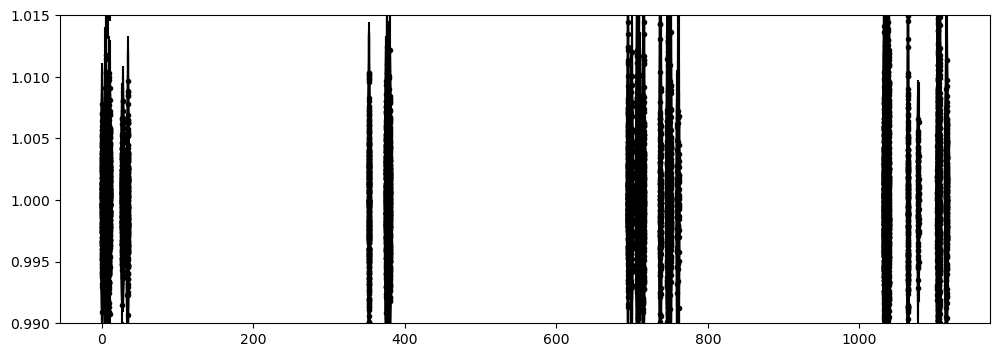

In [3]:
pre_bin = False

all_files = glob.glob(f"{data_dir}/file_*")
all_stars = pd.read_csv(f"{data_dir}/star_info.csv")

#select star/lightcurve to analyse
file_to_use = all_files[0]
file_stem = Path(file_to_use).stem

#get light curve of selected star
data = pd.read_csv(file_to_use)

t = data["bjd"].values - data["bjd"].values[0]
f = data["diff_flux_use"].values
ferr = data["diff_error"].values

#get stellar parameters
star_info = all_stars[all_stars["TARGET"]==file_stem]

R_star = star_info["RAD"].values[0]
M_star = star_info["MASS"].values[0]
T_star = star_info["TEFF"].values[0]

# f *= np.linspace(1,1.01, len(t)) # add a linear trend for the GP to remove
plt.figure(figsize=(12,4))
plt.errorbar(t,f,ferr,fmt='k.')
plt.ylim(0.99,1.015)

In [4]:
targ = LightCurve(name = "secondLC",
                  time = t,
                  flux = f,
                  uncertainty = np.abs(ferr),
                  telescope = "None",
                  filter="None",
                  metadata={'R_star':R_star*u.R_sun, 'M_star':M_star*u.M_sun})

In [4]:
targ_with_transit = targ.inject_transit(per=2.55*u.d, 
                                        epoch=0.025 * u.d, 
                                        inc=90 * u.degree, 
                                        rp=1 * u.R_earth, 
                                        ld=[0.3,0.3])

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


array([<Axes: ylabel='transit_model'>, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: xlabel='Time [d]'>], dtype=object)

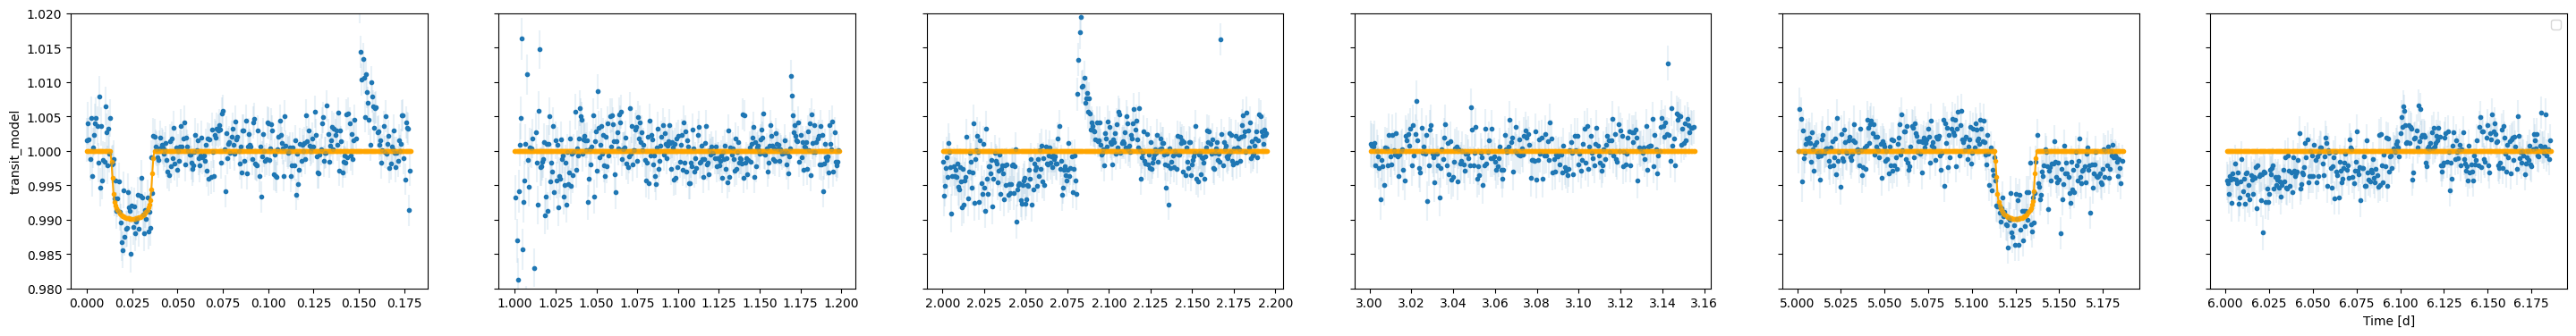

In [7]:
ax=targ_with_transit.plot()
targ_with_transit.plot(quantity="transit_model", color='orange', ax=ax, linestyle="-")

In [5]:
per=2.55*u.d
epoch=0.025 * u.d
inc=90 * u.degree
rp=1 * u.R_earth
ld=[0.3,0.3]

planets = targ_with_transit.create_lots_of_transit_params(nfake=1, 
                                                          minimum_planet_radius=rp, 
                                                          maximum_planet_radius=rp,
                                                          minimum_period=per, 
                                                          maximum_period=per,
                                                        )
planets

,logP,phase,cosi,r_p,depth,duration,epoch,a,a_Rs,injected,...,rec_depth,rec_duration,rec_epoch,run,snr,target,r_s,m_s,teff,spt
0,0.40654,0.797768,0.000455,1.0,0.008405017877225193,0.024305,2.034308,3.6458425652160784 solRad,36.458425652160784,0.0,...,0.0,0.0,0.0,0.0,0.0,secondLC_inject,0.1 solRad,0.1 solMass,None,None


1/5...


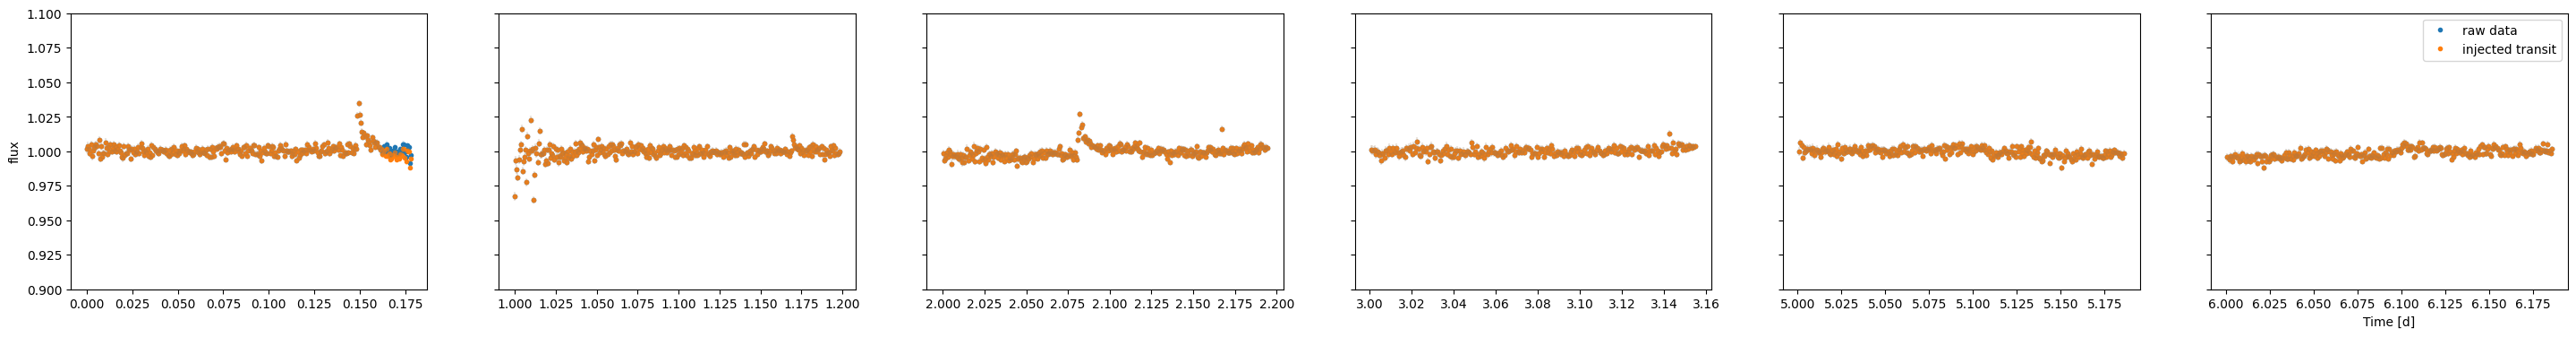

Masking NaN fluxes...
Masking zero fluxes...
Masking cosmic ray hits...



            0.05230125523012552% of data is flagged as cosmics ⚡.
            
Time to clean LC: 0.6327741146087646


/Users/catrionamurray/anaconda3/envs/occultence/lib/python3.9/site-packages/numpy/core/fromnumeric.py:784: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



            There are 2 flare candidates with >30.0 s over 3$\sigma$
            


Time to remove flares: 0.6688549518585205


/Users/catrionamurray/anaconda3/envs/occultence/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a, func=_nanmedian, keepdims=keepdims,


Running BLS Search
Number of Periods Checked:  47143
Period:  0.20885351765216892
Duration:  0.04
Depth:  0.0027284603769505036
Power:  5.138152601589148


/Users/catrionamurray/anaconda3/envs/occultence/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


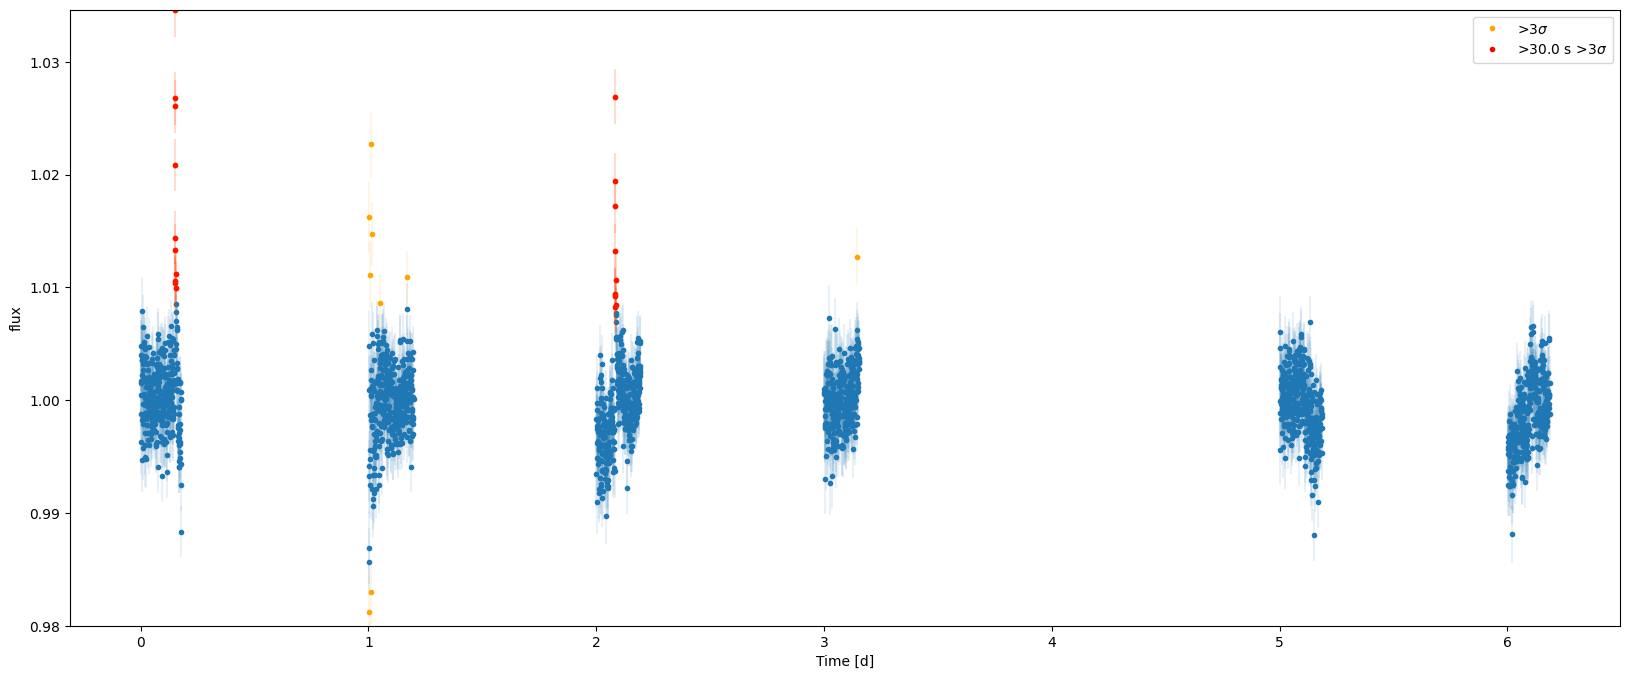

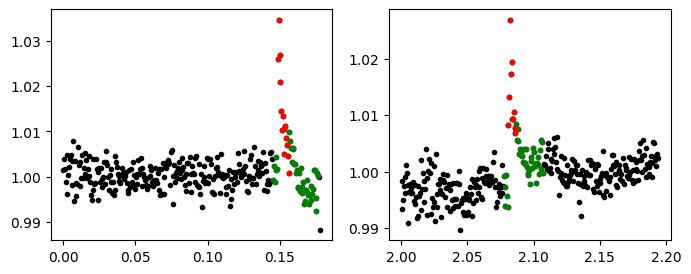

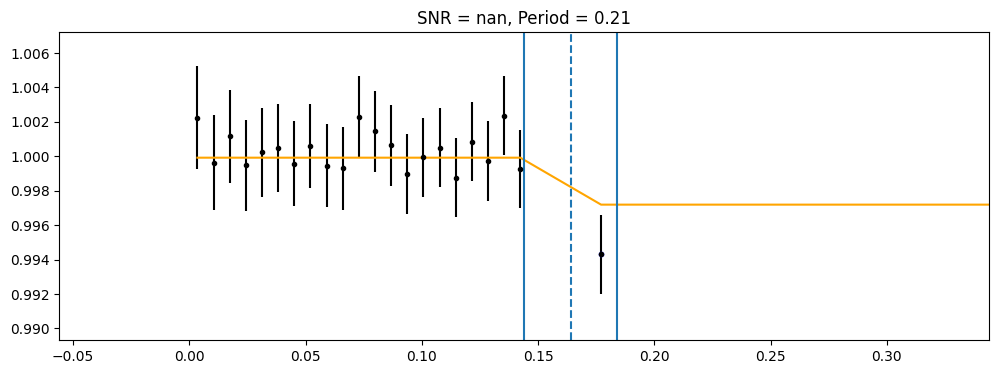

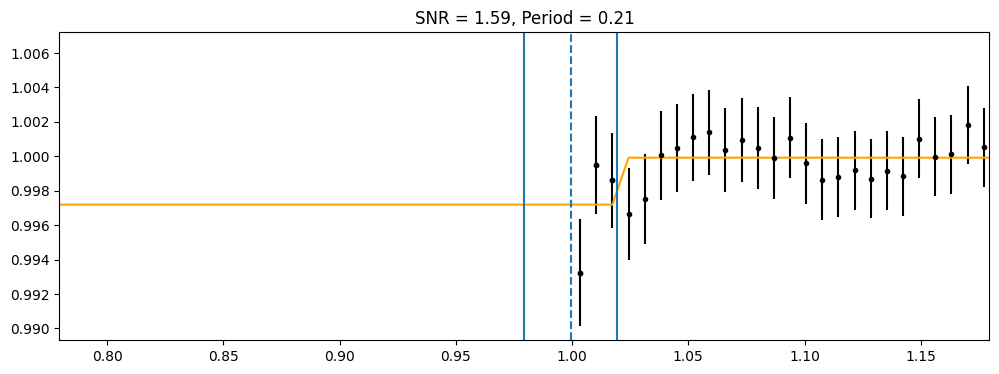

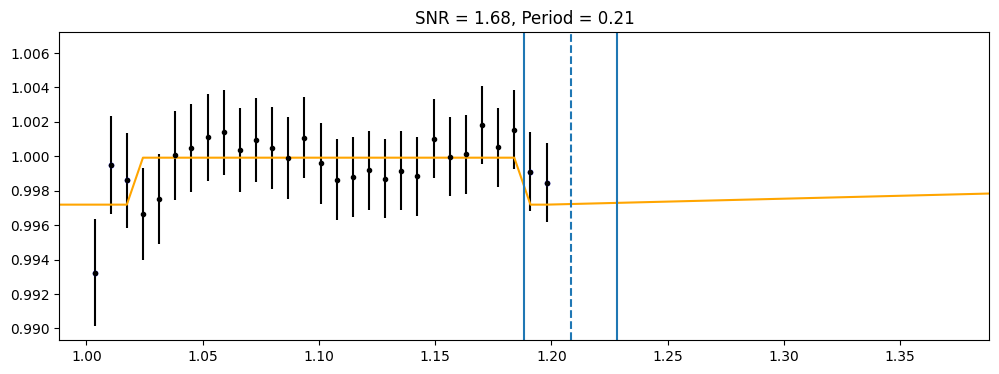

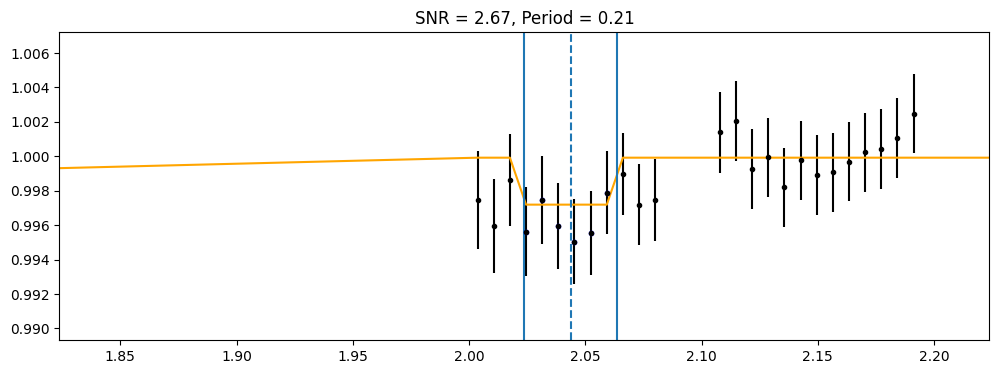

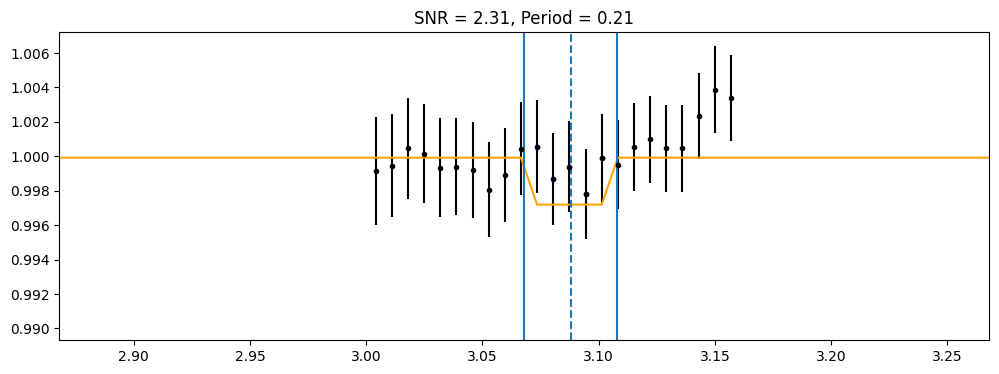

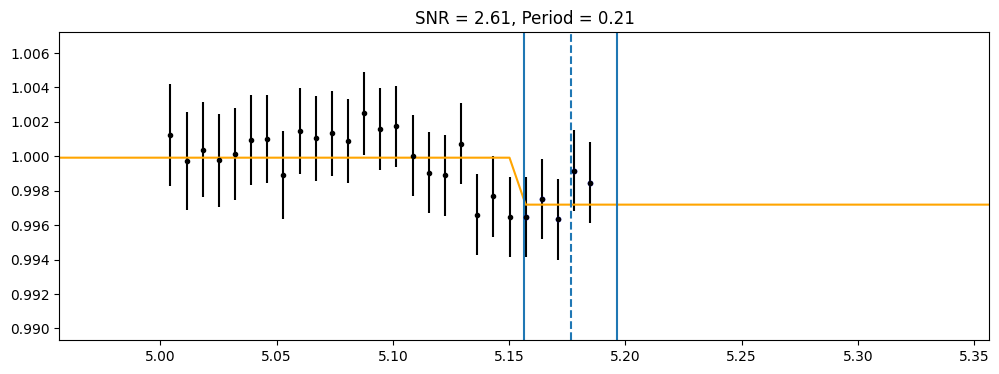

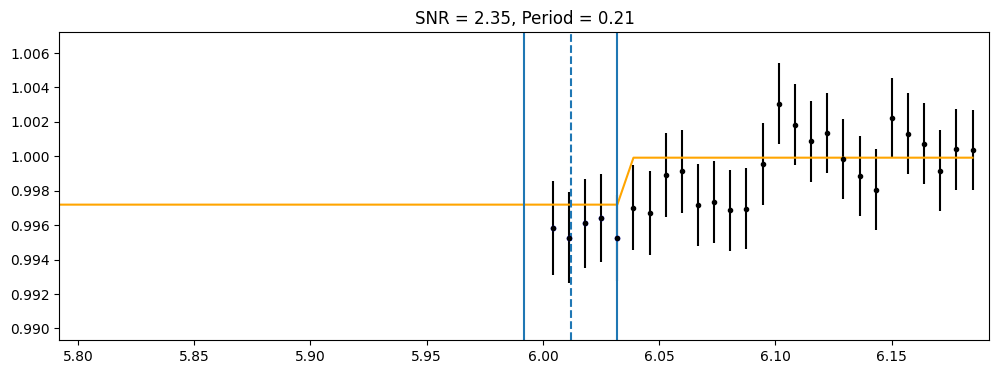

Time to BLS before detrending: 1.6963951587677002
Fitting rotation with square-exponential GP...
Initial Parameter Vector:  [-6.04074927 -6.49522508 -2.30258509]
Initial Params: AMP =  0.0015106351671618236 , SQEXP=  0.10000000000000002 , JITTER =  0.0023797751449578497
Initial ln-likelihood: 251.75
Fitted GP HPs: [-27.7027425  -26.87655283  -1.54782533]
Fitted Params: AMP =  2.12648053763699e-12 , SQEXP=  0.2127100448997134 , JITTER =  9.307901964395534e-13
Final ln-likelihood: 607.41


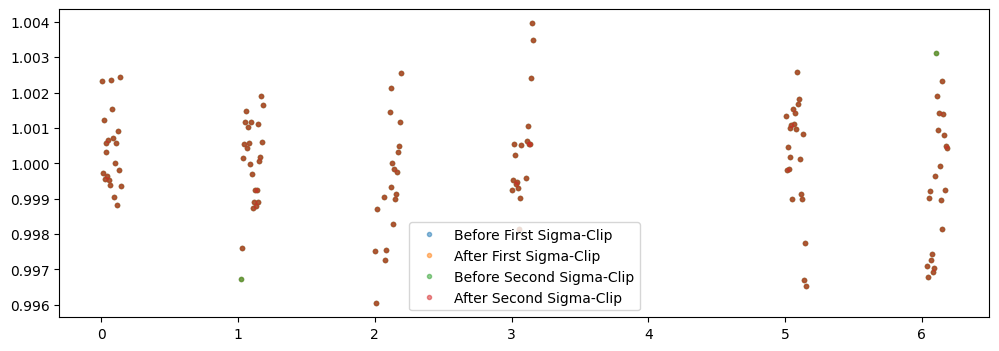

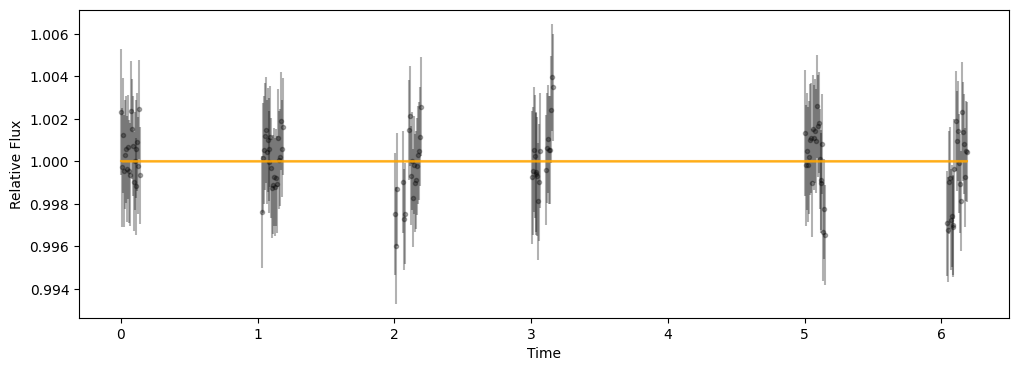

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Time to detrend: 1.9765868186950684


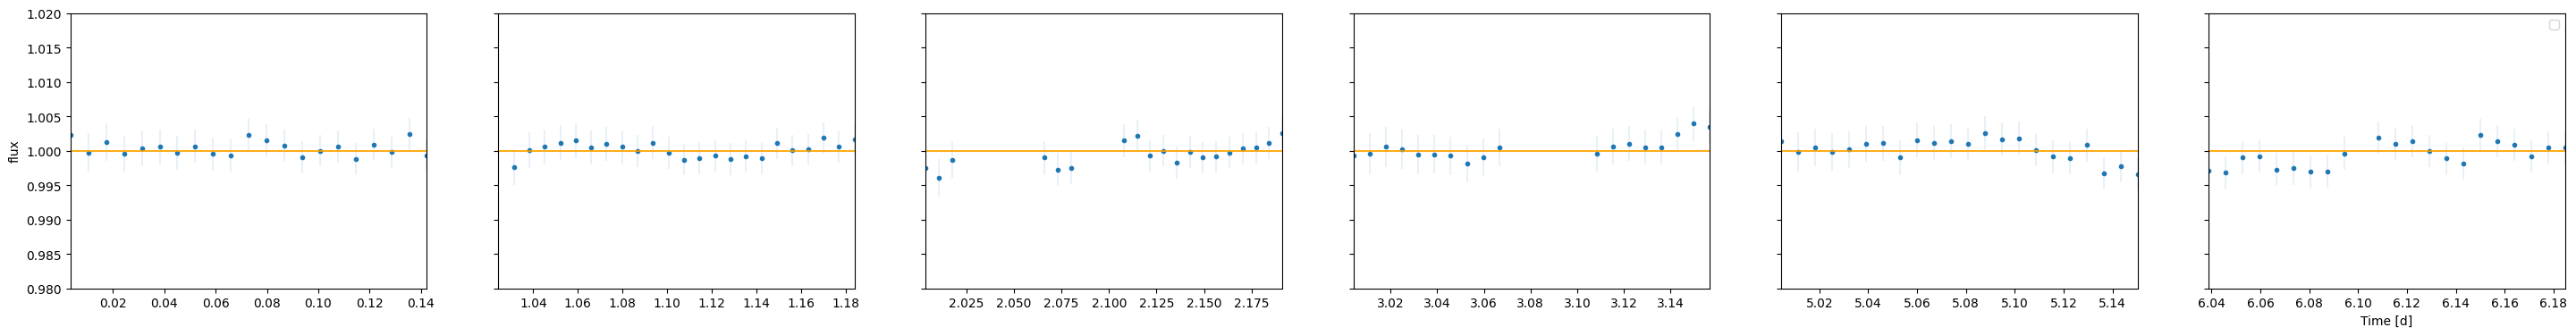

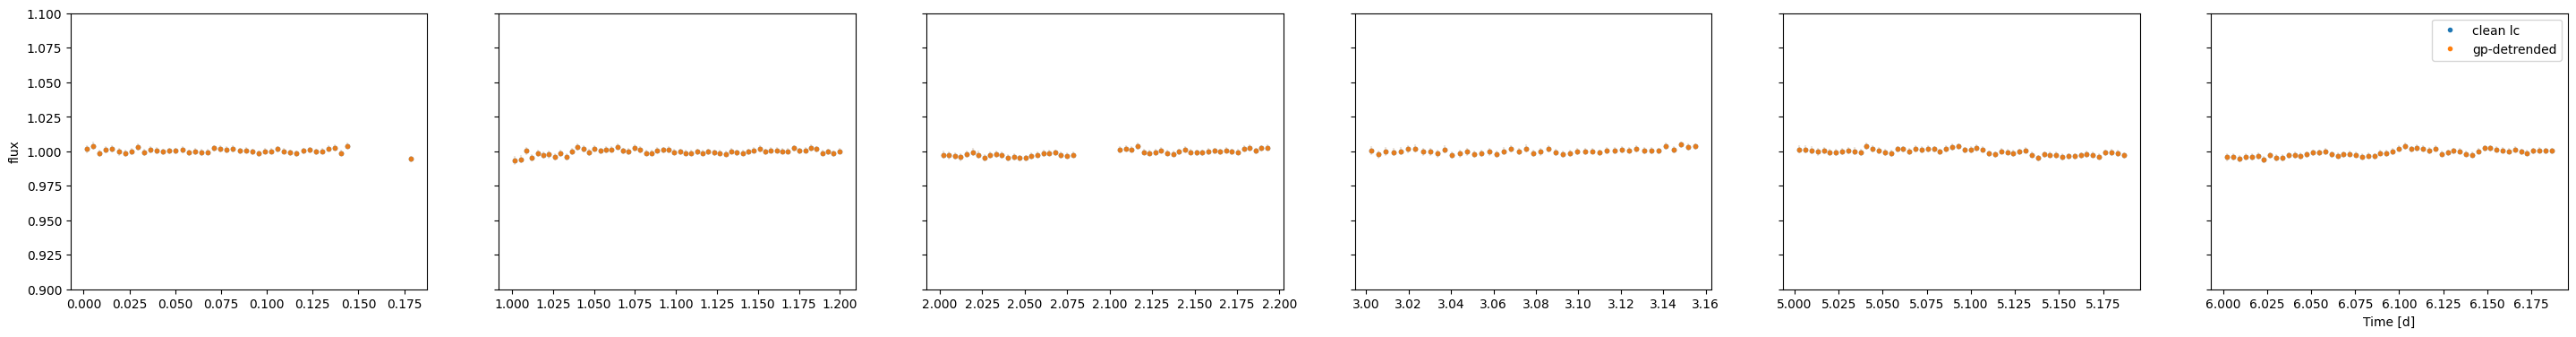

Running BLS Search
Number of Periods Checked:  47196
Period:  0.20836302880070387
Duration:  0.04
Depth:  0.002710858477688068
Power:  7.0535959499809415


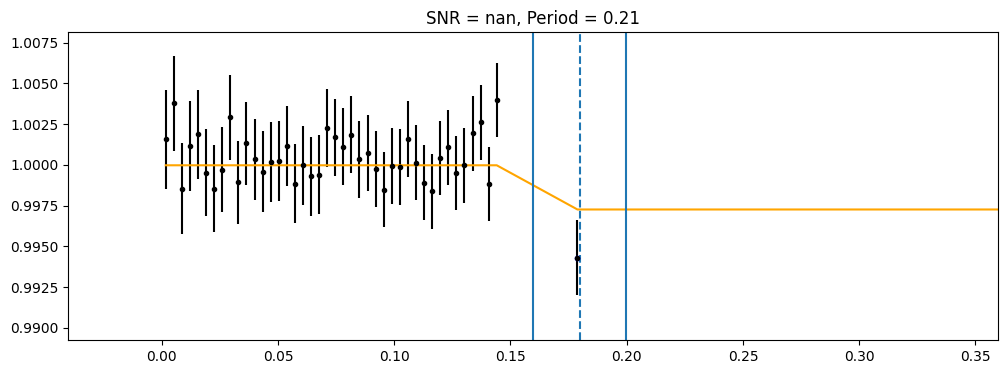

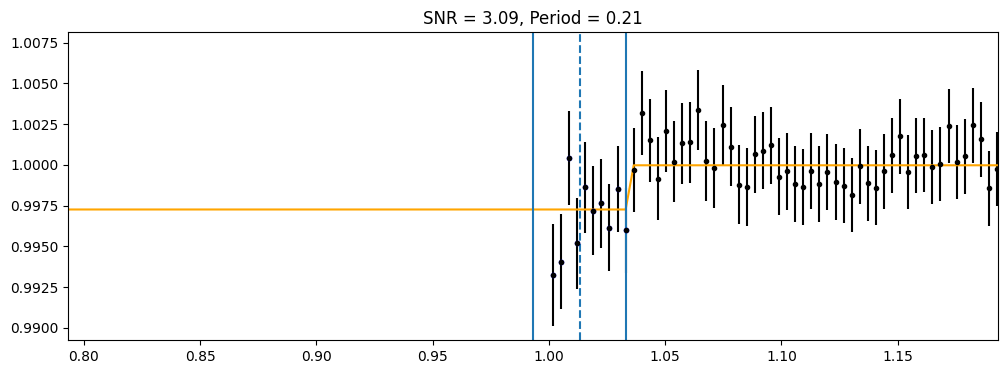

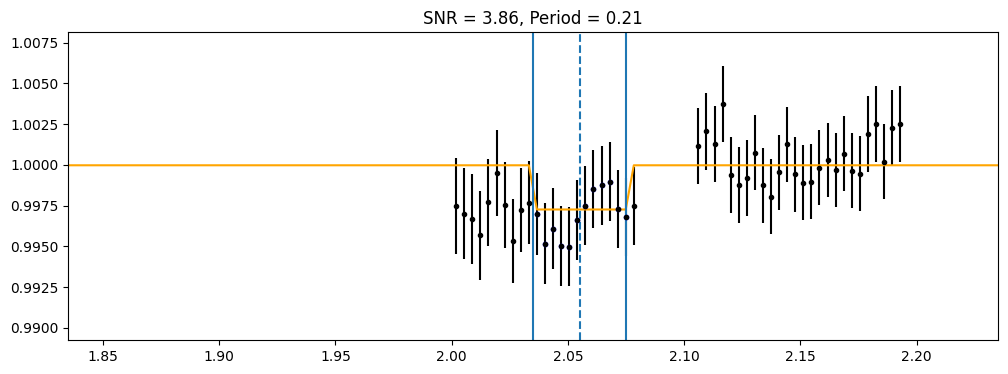

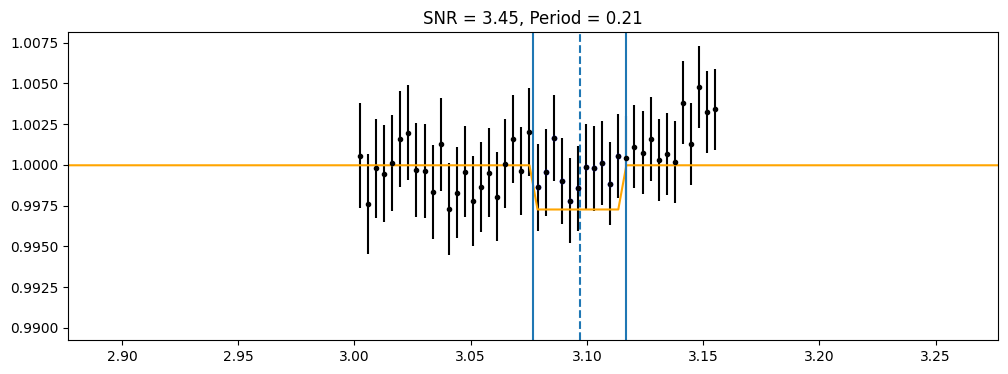

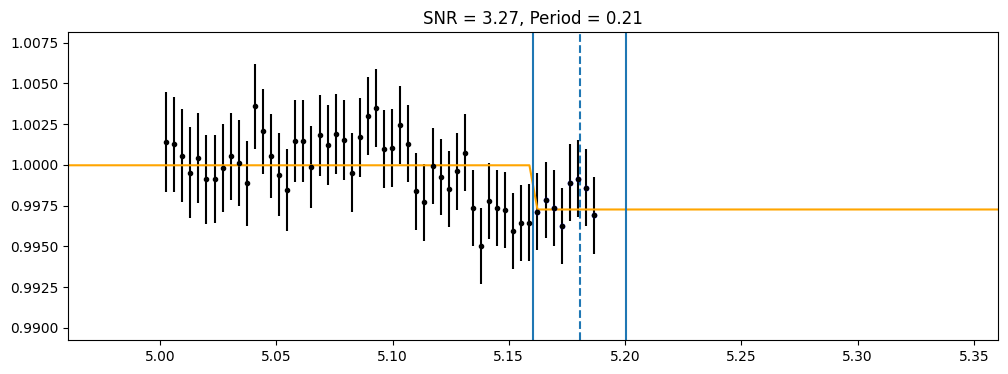

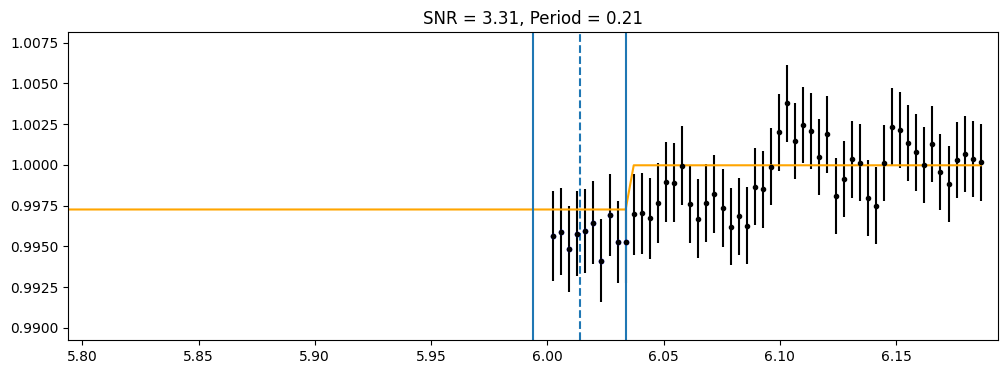

Time to BLS search: 1.4722797870635986
Transit was found - checking if it matches the injected transit!
Planet was successfully recovered
No transit found!

2/5...


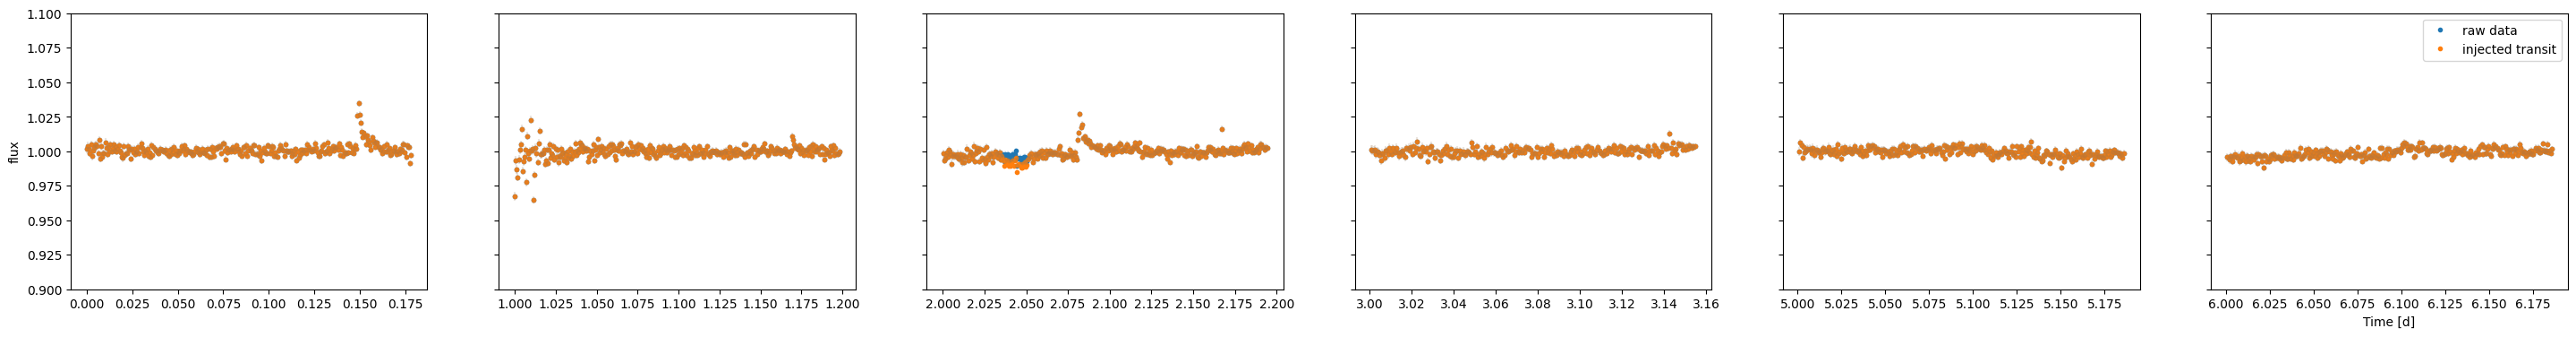

Masking NaN fluxes...
Masking zero fluxes...
Masking cosmic ray hits...


/Users/catrionamurray/anaconda3/envs/occultence/lib/python3.9/site-packages/numpy/core/fromnumeric.py:784: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



            0.05230125523012552% of data is flagged as cosmics ⚡.
            
Time to clean LC: 0.648292064666748


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



            There are 2 flare candidates with >30.0 s over 3$\sigma$
            


Time to remove flares: 0.6822779178619385


/Users/catrionamurray/anaconda3/envs/occultence/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a, func=_nanmedian, keepdims=keepdims,


Running BLS Search
Number of Periods Checked:  47143
Period:  0.5688909997591054
Duration:  0.04
Depth:  0.004663554439229041
Power:  5.873923362547715


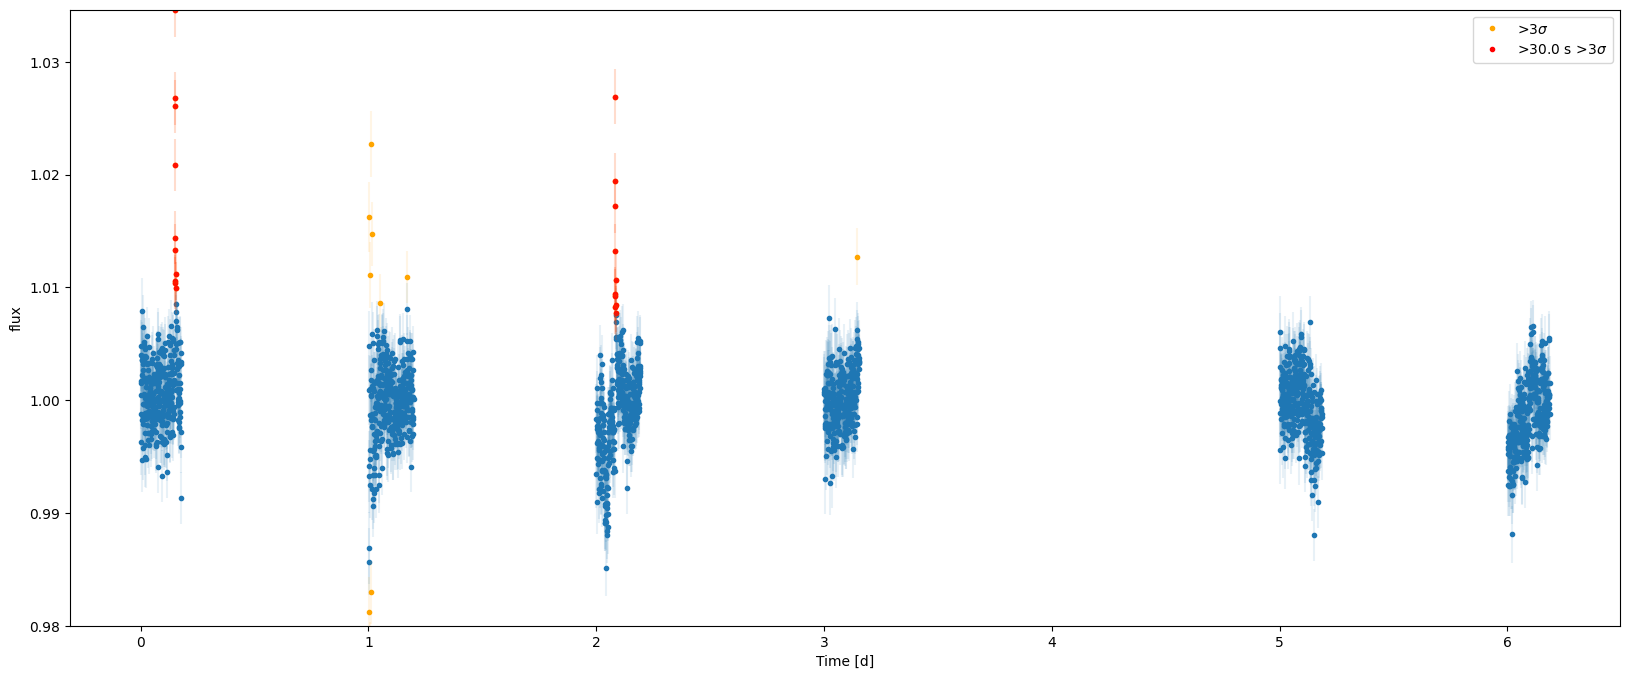

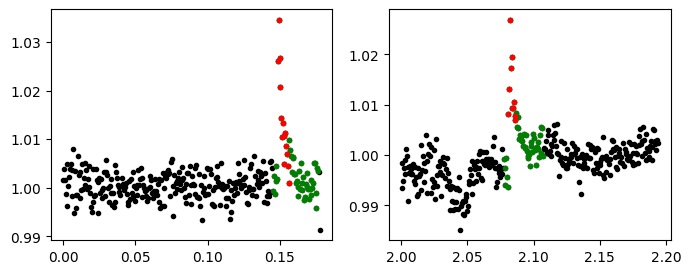

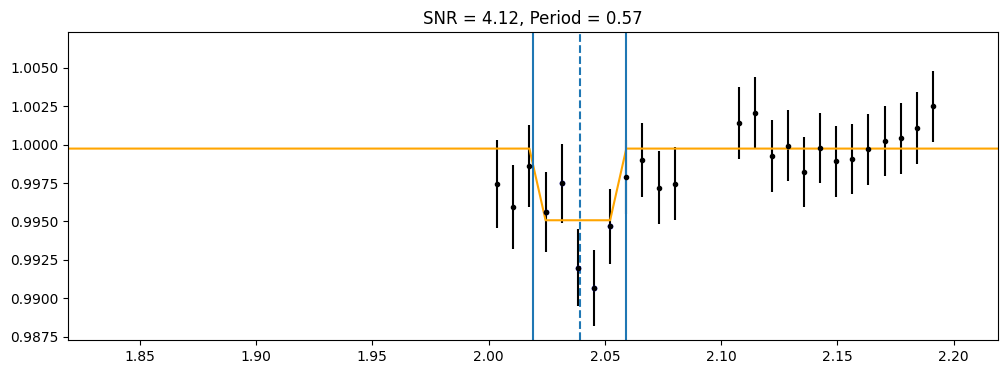

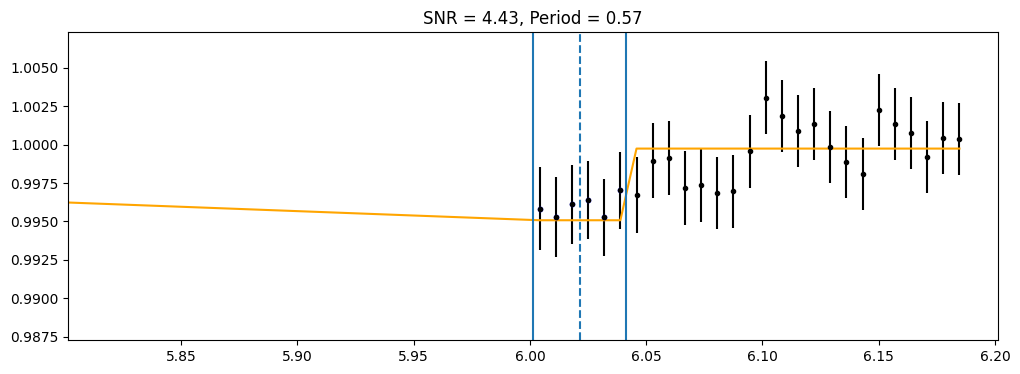

Time to BLS before detrending: 1.1120550632476807
Fitting rotation with square-exponential GP...
Initial Parameter Vector:  [-6.04118268 -6.47864981 -2.30258509]
Initial Params: AMP =  0.0015358830083137996 , SQEXP=  0.10000000000000002 , JITTER =  0.0023787439578714506
Initial ln-likelihood: 282.74
Fitted GP HPs: [-27.5838957  -29.91773315  -0.76114791]
Fitted Params: AMP =  1.0159997101837824e-13 , SQEXP=  0.46712989479494693 , JITTER =  1.048253468763627e-12
Final ln-likelihood: 679.57


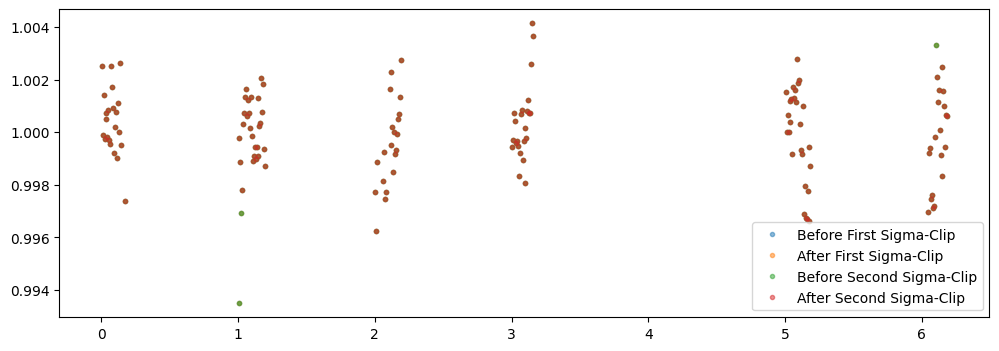

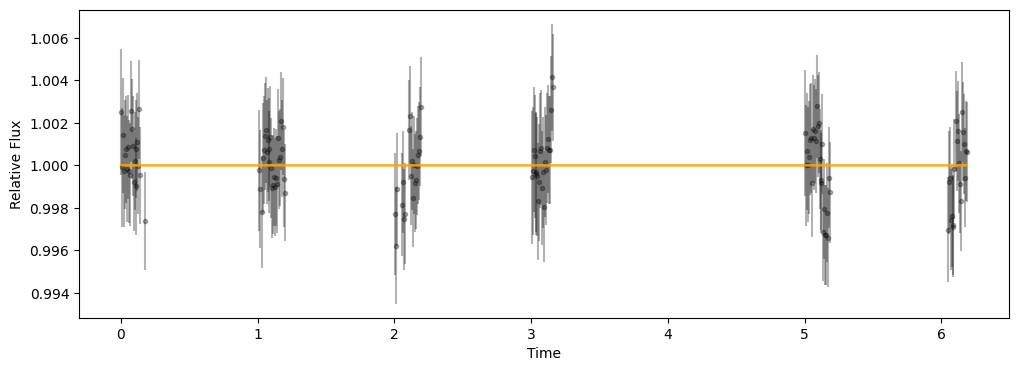

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Time to detrend: 1.8832769393920898


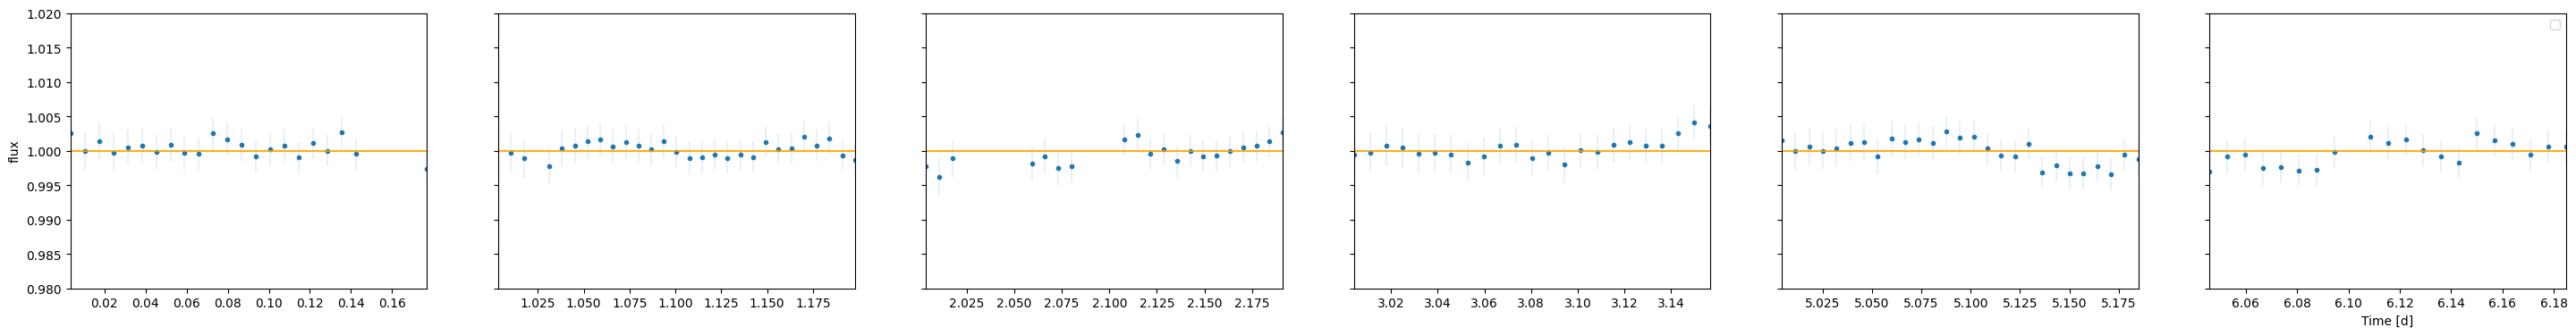

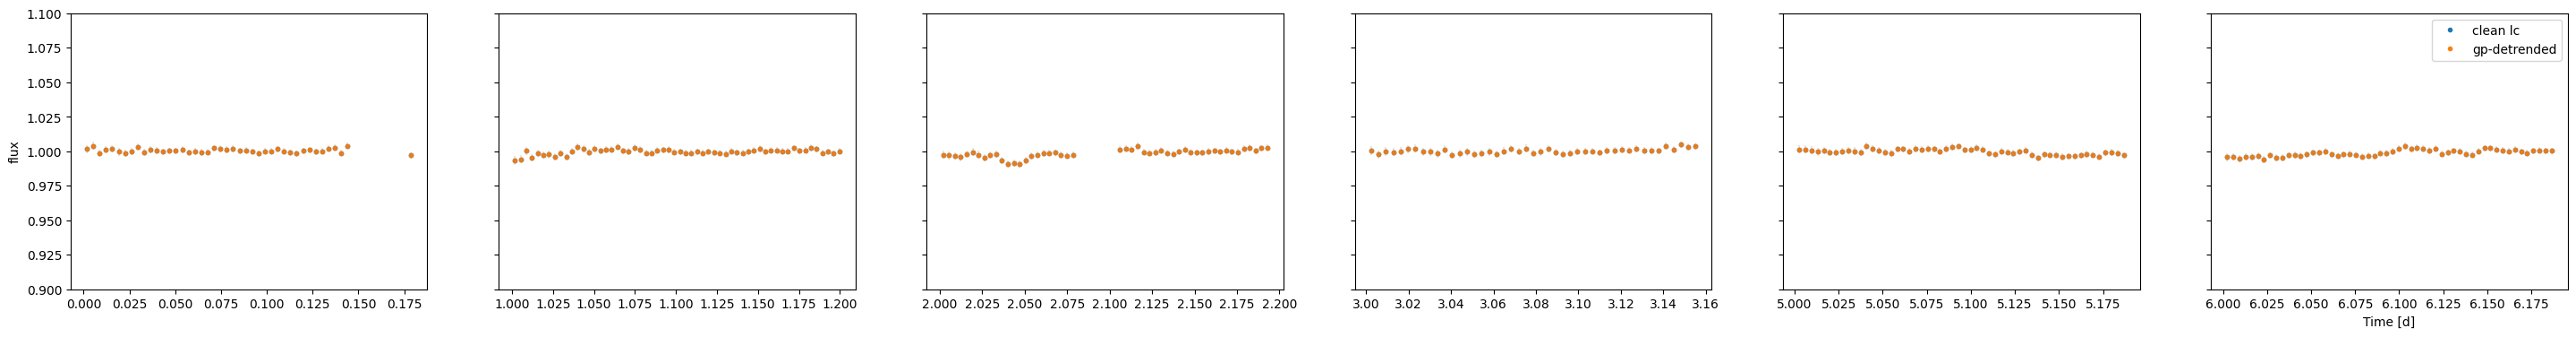

Running BLS Search
Number of Periods Checked:  47196
Period:  0.796080607984286
Duration:  0.04
Depth:  0.004561752961810148
Power:  8.307499305074021


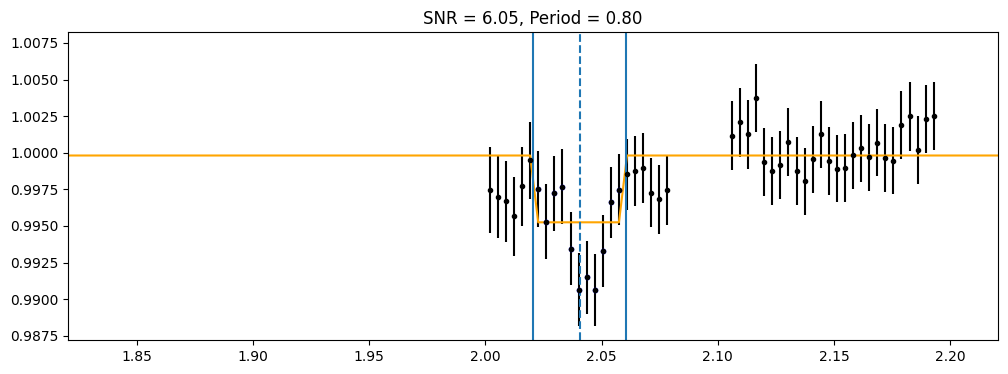

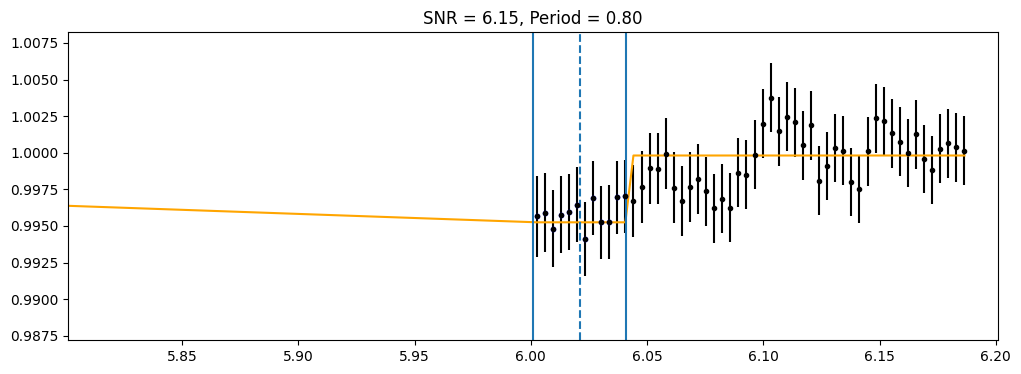

Time to BLS search: 0.8981692790985107
Transit was found - checking if it matches the injected transit!
Planet was successfully recovered
No transit found!

3/5...


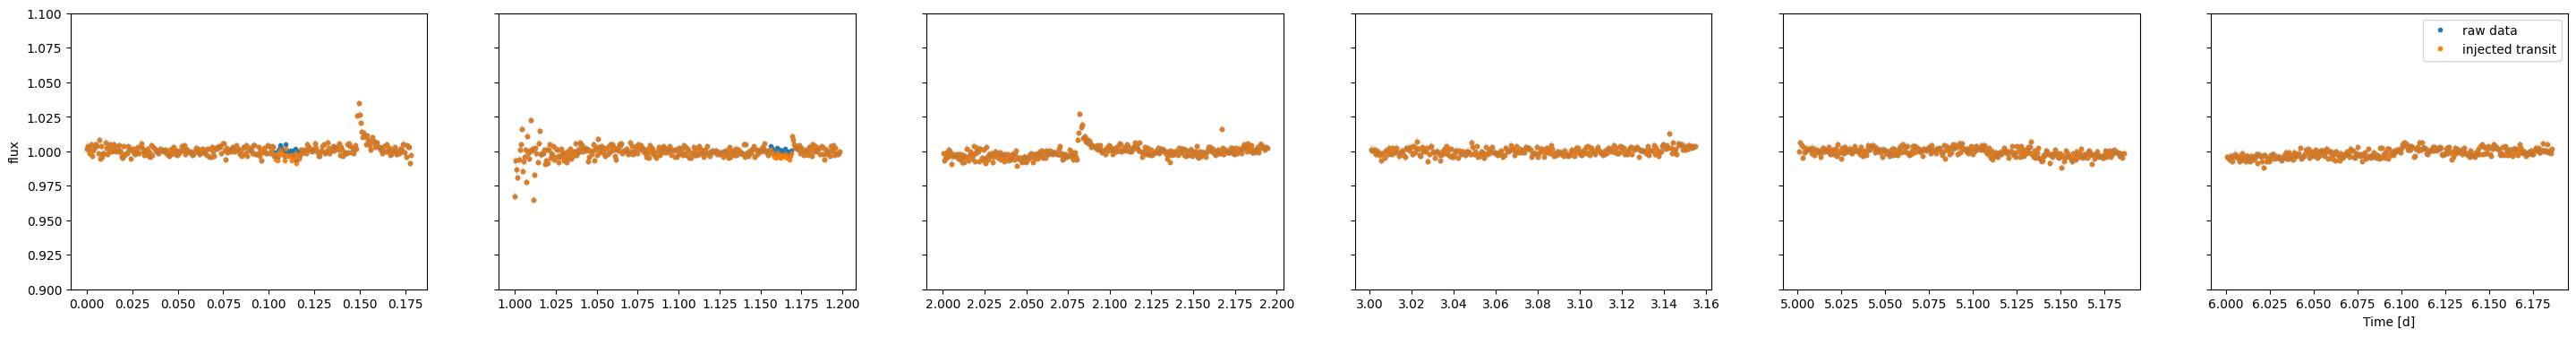

Masking NaN fluxes...
Masking zero fluxes...
Masking cosmic ray hits...


/Users/catrionamurray/anaconda3/envs/occultence/lib/python3.9/site-packages/numpy/core/fromnumeric.py:784: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



            0.05230125523012552% of data is flagged as cosmics ⚡.
            
Time to clean LC: 0.625046968460083


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



            There are 2 flare candidates with >30.0 s over 3$\sigma$
            


Time to remove flares: 0.6709940433502197


/Users/catrionamurray/anaconda3/envs/occultence/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a, func=_nanmedian, keepdims=keepdims,


Running BLS Search
Number of Periods Checked:  47143
Period:  0.20885351765216892
Duration:  0.04
Depth:  0.0025206731868390006
Power:  4.746854160729406
No transits detected!
Time to BLS before detrending: 0.6815450191497803
Fitting rotation with square-exponential GP...
Initial Parameter Vector:  [-6.03156251 -6.30543824 -2.30258509]
Initial Params: AMP =  0.00182634561585781 , SQEXP=  0.10000000000000002 , JITTER =  0.002401738295672499
Initial ln-likelihood: 306.18
Fitted GP HPs: [-29.22436092 -12.70001607  -3.87120101]
Fitted Params: AMP =  3.0510765413337956e-06 , SQEXP=  0.02083333333333333 , JITTER =  2.032456756271461e-13
Final ln-likelihood: 728.60


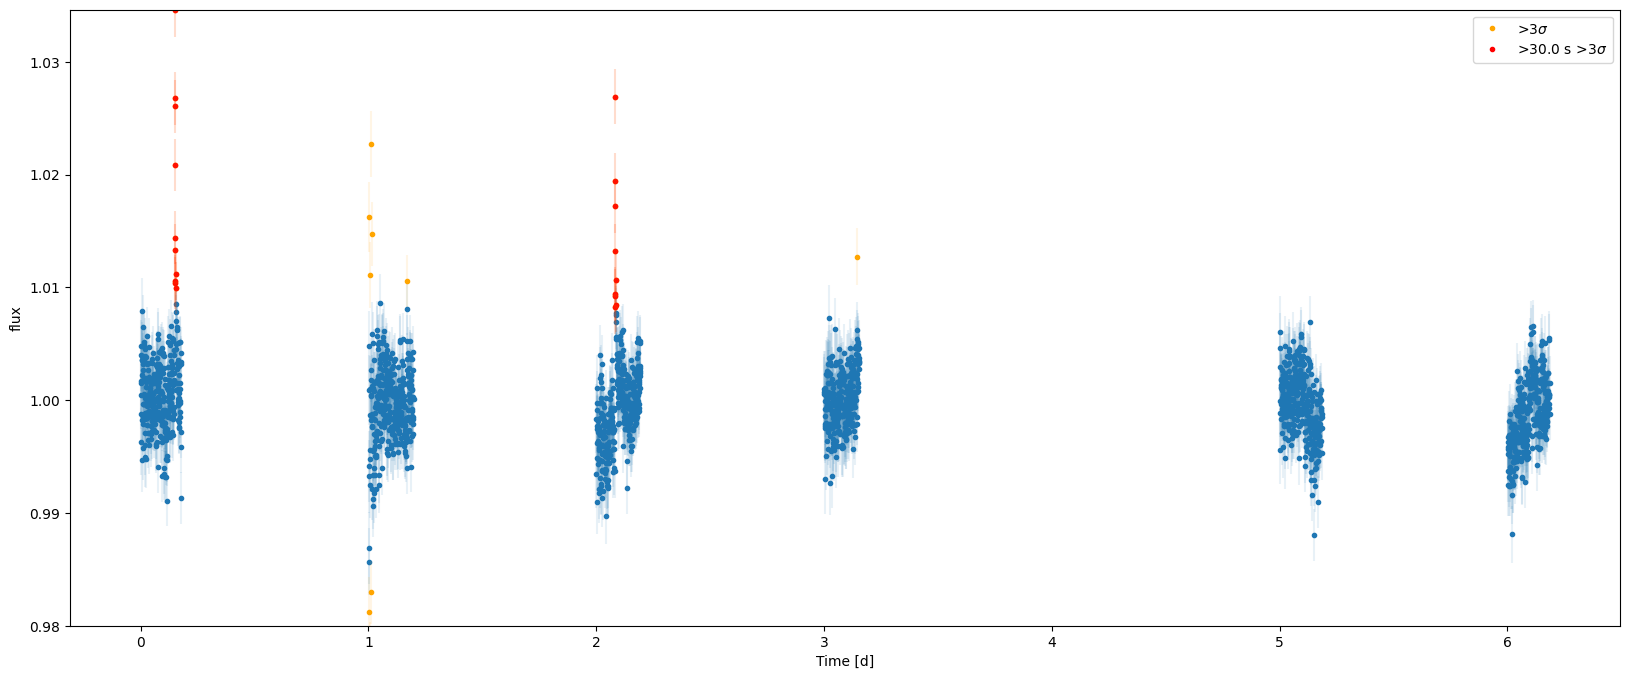

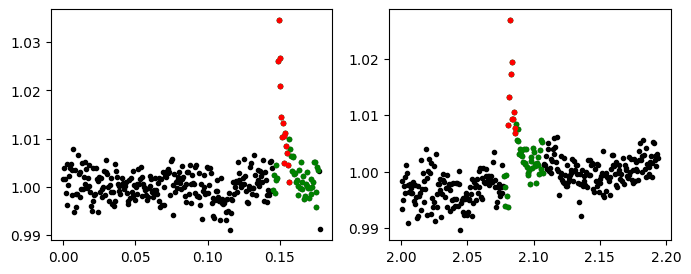

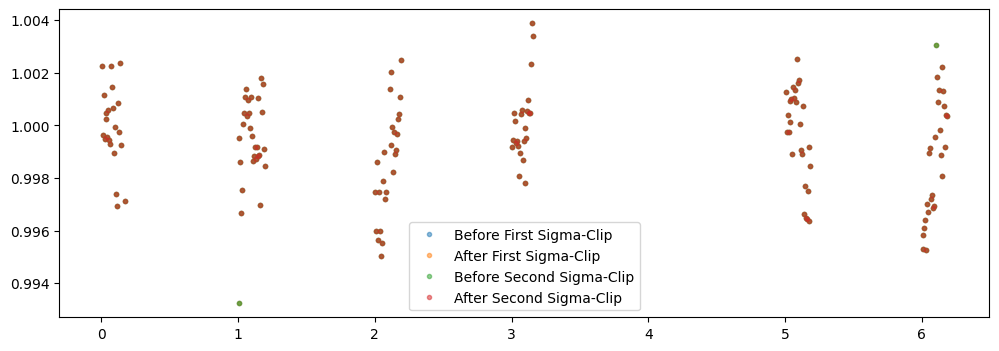

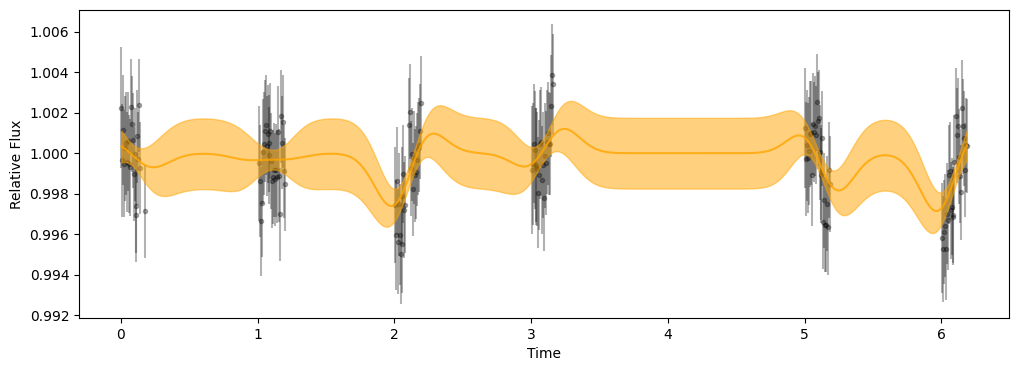

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Time to detrend: 2.03187894821167


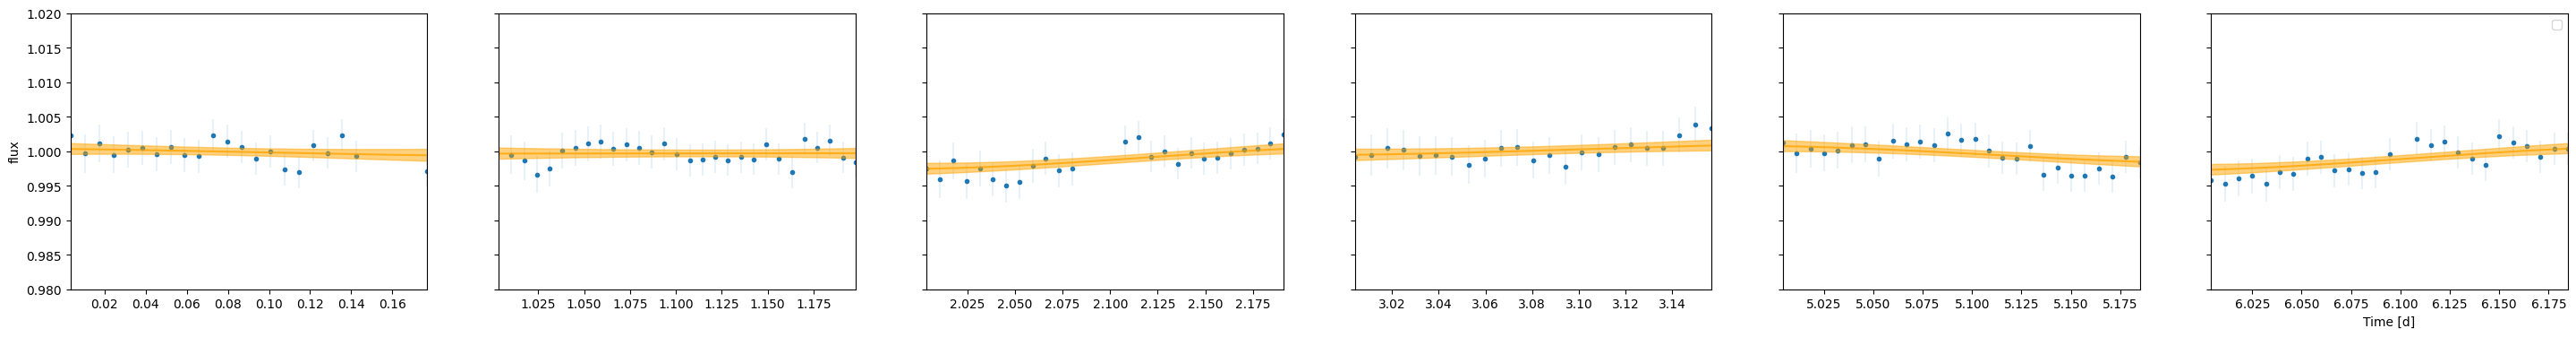

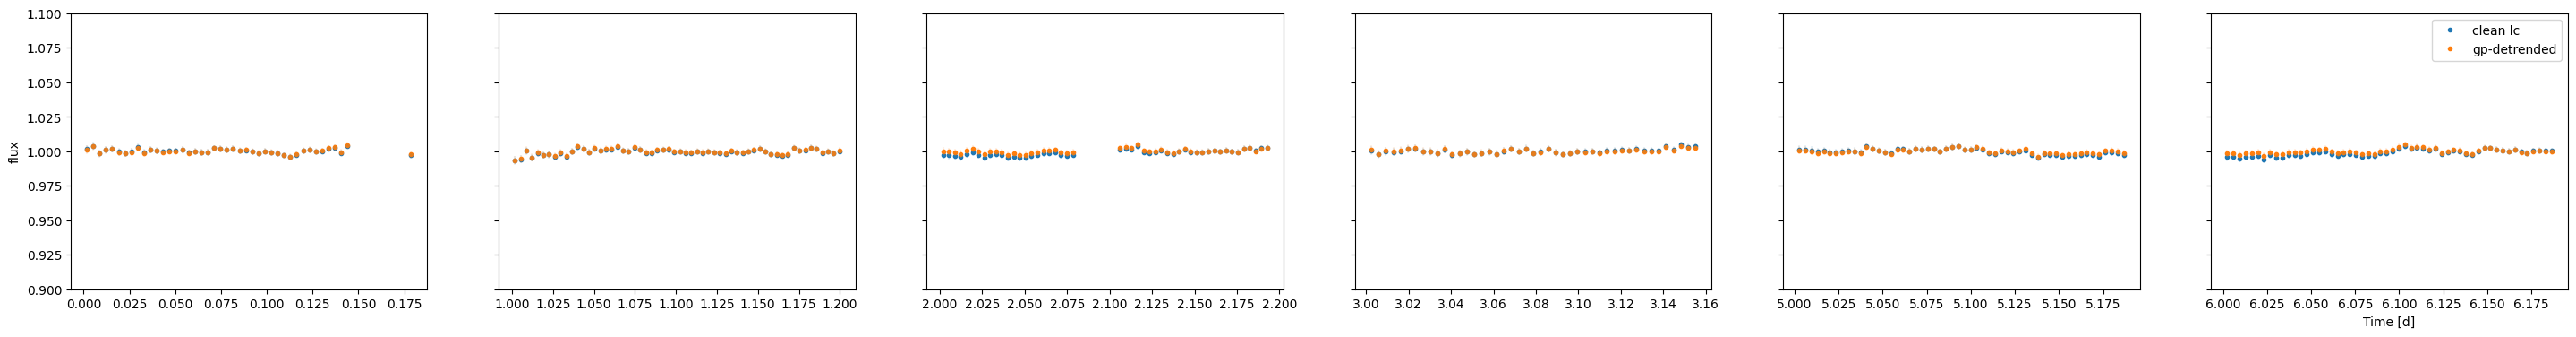

Running BLS Search
Number of Periods Checked:  47196
Period:  0.8279587506482546
Duration:  0.04
Depth:  0.002501045649694327
Power:  4.620824261485404
No transits detected!
Time to BLS search: 0.7276010513305664
No transit found!

4/5...


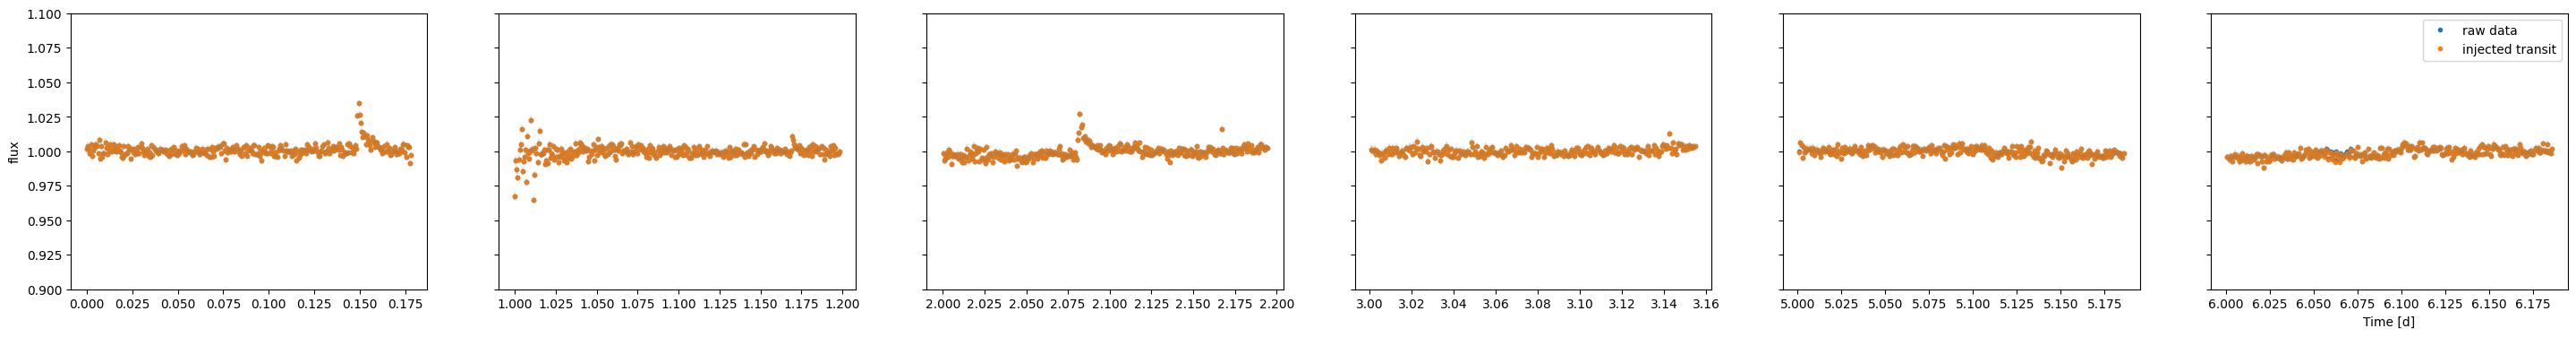

Masking NaN fluxes...
Masking zero fluxes...
Masking cosmic ray hits...



            0.05230125523012552% of data is flagged as cosmics ⚡.
            
Time to clean LC: 0.6192069053649902


/Users/catrionamurray/anaconda3/envs/occultence/lib/python3.9/site-packages/numpy/core/fromnumeric.py:784: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



            There are 2 flare candidates with >30.0 s over 3$\sigma$
            


Time to remove flares: 0.6696569919586182


/Users/catrionamurray/anaconda3/envs/occultence/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a, func=_nanmedian, keepdims=keepdims,


Running BLS Search
Number of Periods Checked:  47143
Period:  0.20885351765216892
Duration:  0.04
Depth:  0.0025894108177117567
Power:  4.876298751488194
No transits detected!
Time to BLS before detrending: 0.6745452880859375
Fitting rotation with square-exponential GP...
Initial Parameter Vector:  [-6.03156251 -6.31410616 -2.30258509]
Initial Params: AMP =  0.0018105834174173311 , SQEXP=  0.10000000000000002 , JITTER =  0.002401738295672499
Initial ln-likelihood: 306.22
Fitted GP HPs: [-26.82433436 -12.68079513  -3.87120101]
Fitted Params: AMP =  3.11028833067672e-06 , SQEXP=  0.02083333333333333 , JITTER =  2.2404724398665e-12
Final ln-likelihood: 730.58


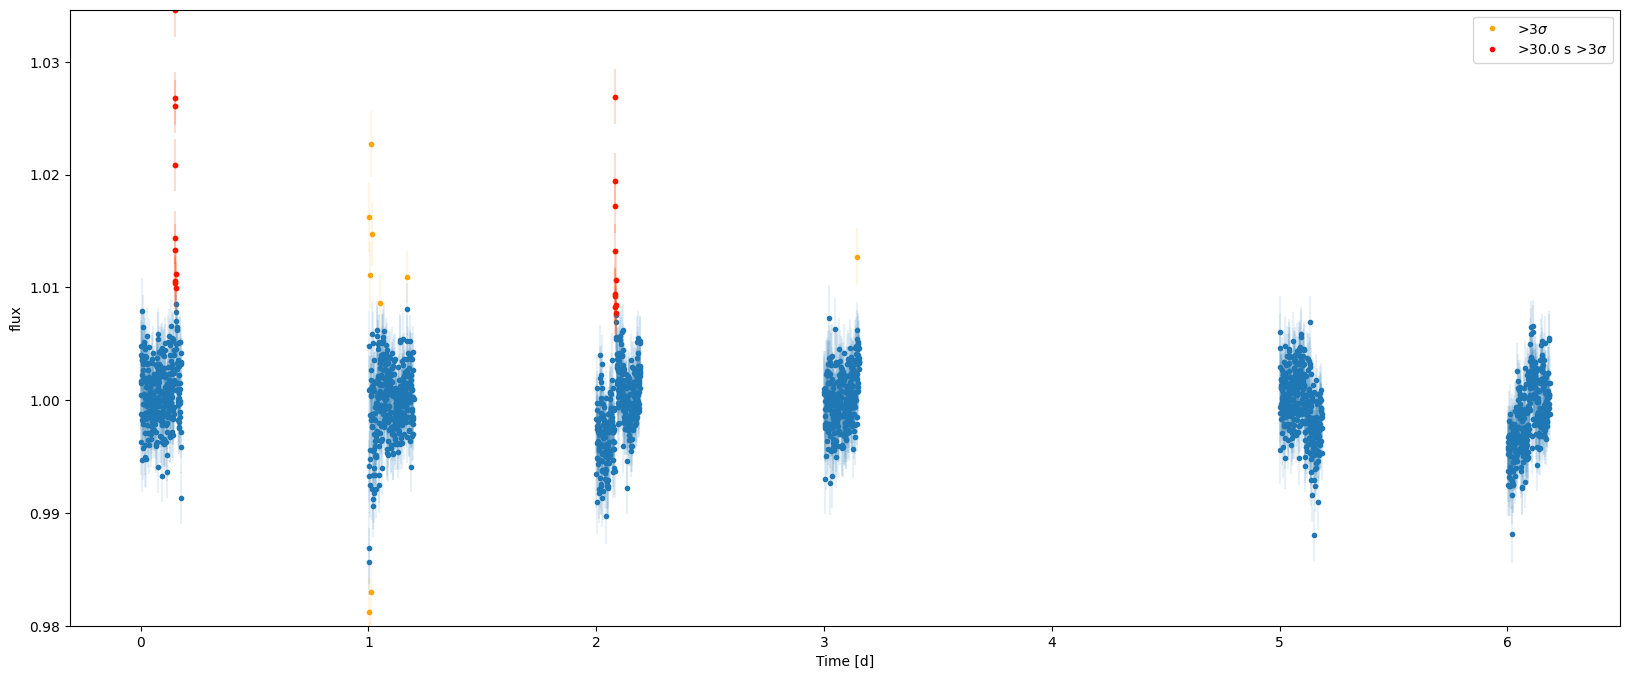

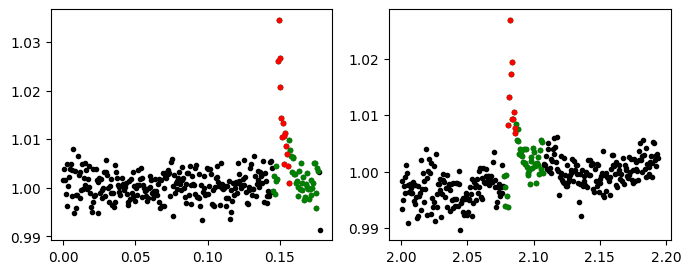

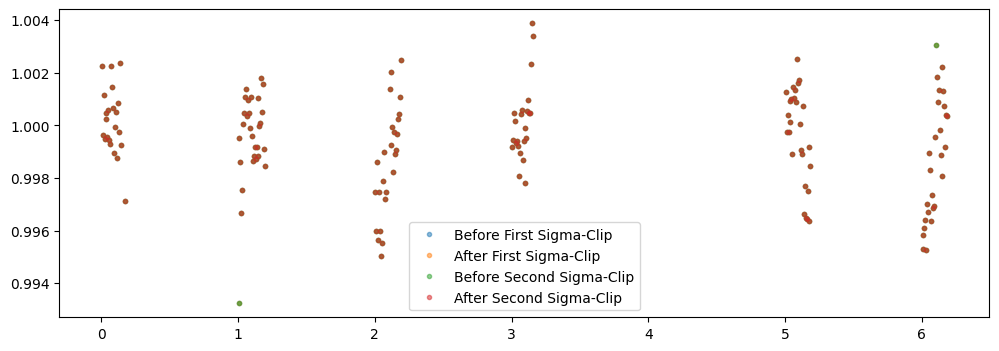

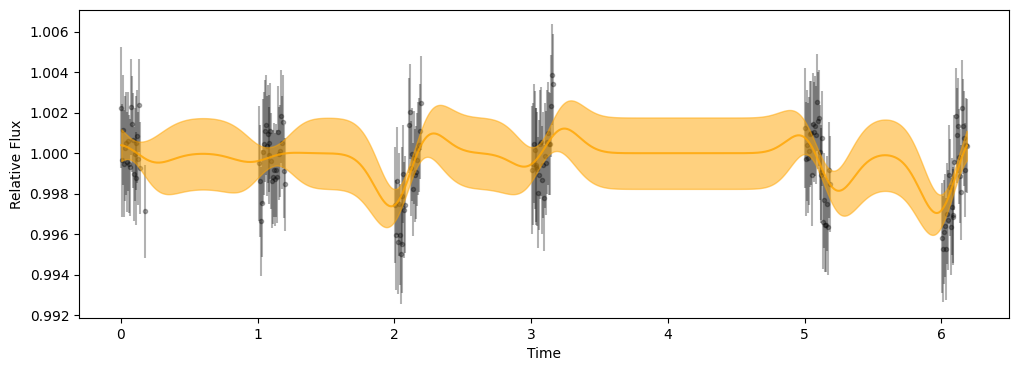

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Time to detrend: 2.252250909805298


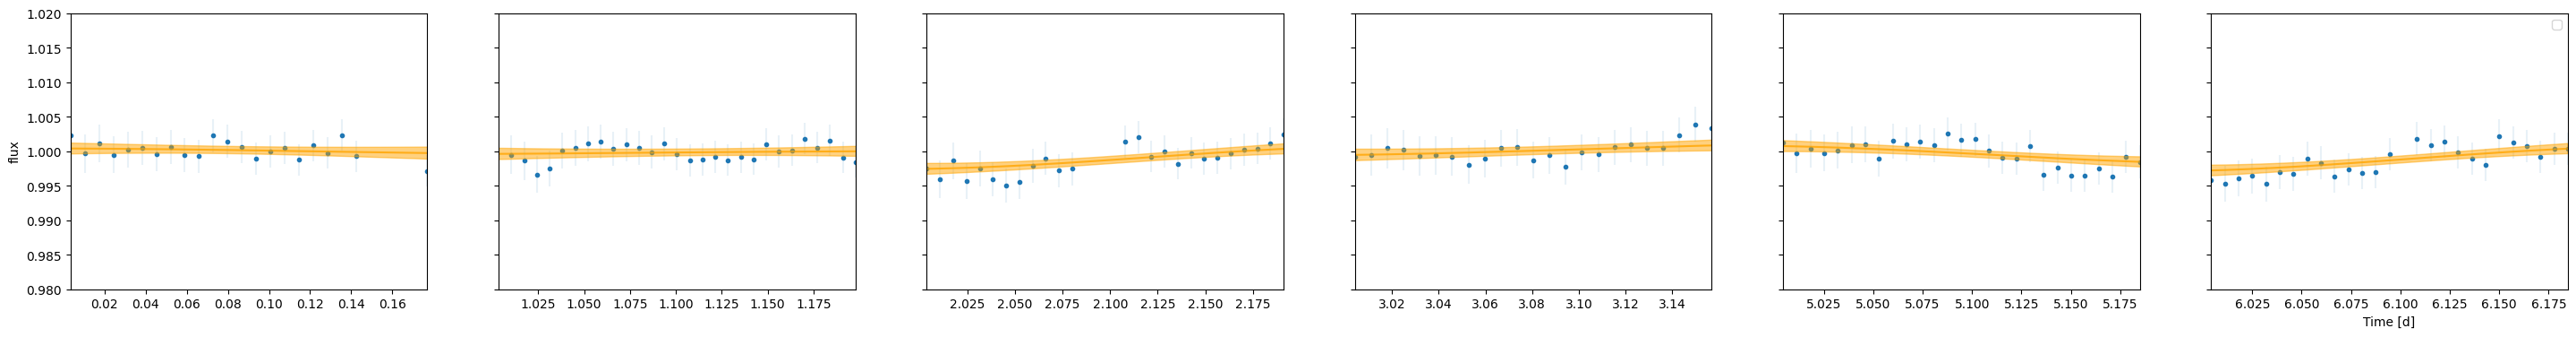

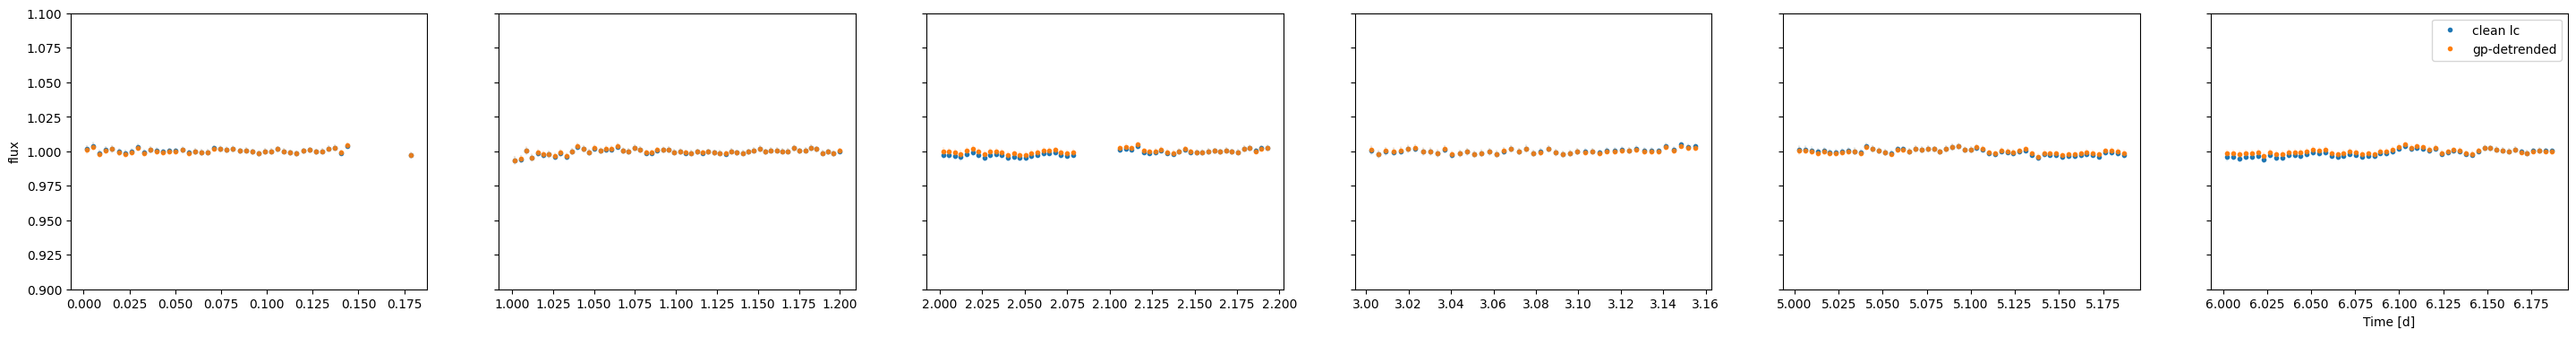

Running BLS Search
Number of Periods Checked:  47196
Period:  0.8277795750171663
Duration:  0.04
Depth:  0.0025307180188946917
Power:  4.675645653295491
No transits detected!
Time to BLS search: 0.7261128425598145
No transit found!

5/5...


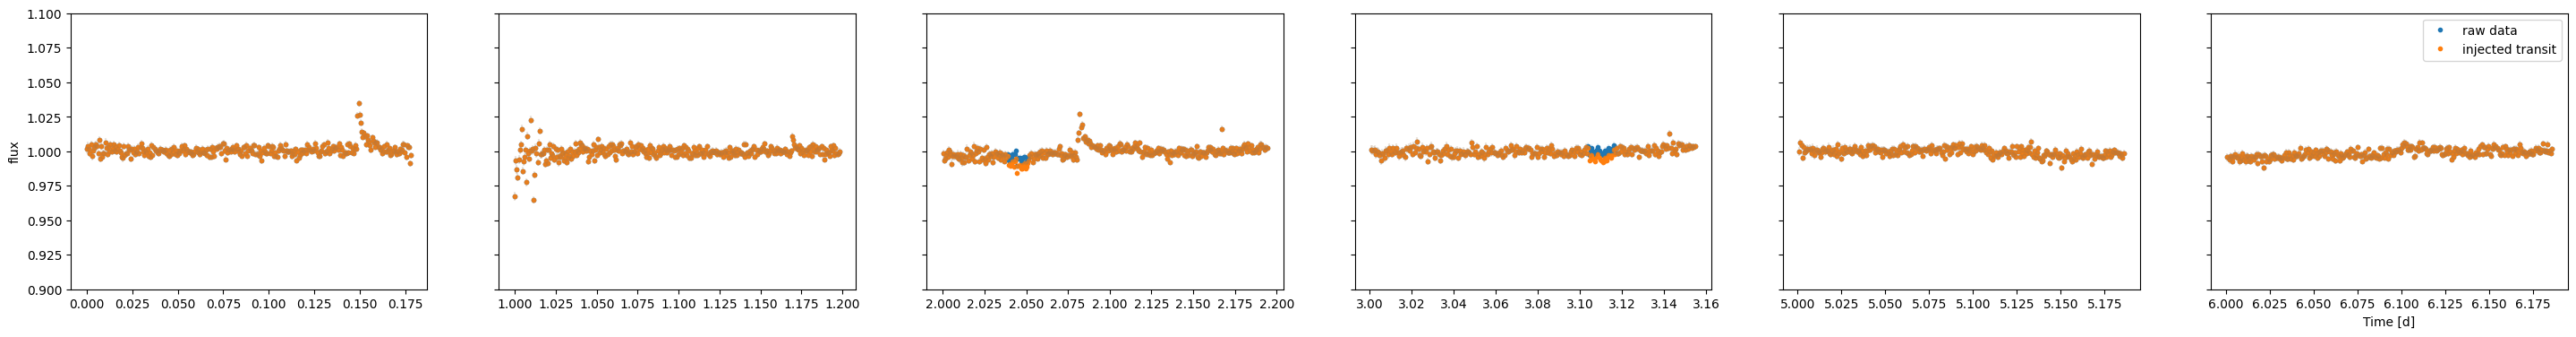

Masking NaN fluxes...
Masking zero fluxes...
Masking cosmic ray hits...



            0.05230125523012552% of data is flagged as cosmics ⚡.
            
Time to clean LC: 0.7615480422973633


/Users/catrionamurray/anaconda3/envs/occultence/lib/python3.9/site-packages/numpy/core/fromnumeric.py:784: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



            There are 2 flare candidates with >30.0 s over 3$\sigma$
            


Time to remove flares: 0.846045970916748


/Users/catrionamurray/anaconda3/envs/occultence/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a, func=_nanmedian, keepdims=keepdims,


Running BLS Search
Number of Periods Checked:  47143
Period:  0.2645400309529891
Duration:  0.04
Depth:  0.003847421209279671
Power:  6.020144405809637


/Users/catrionamurray/anaconda3/envs/occultence/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


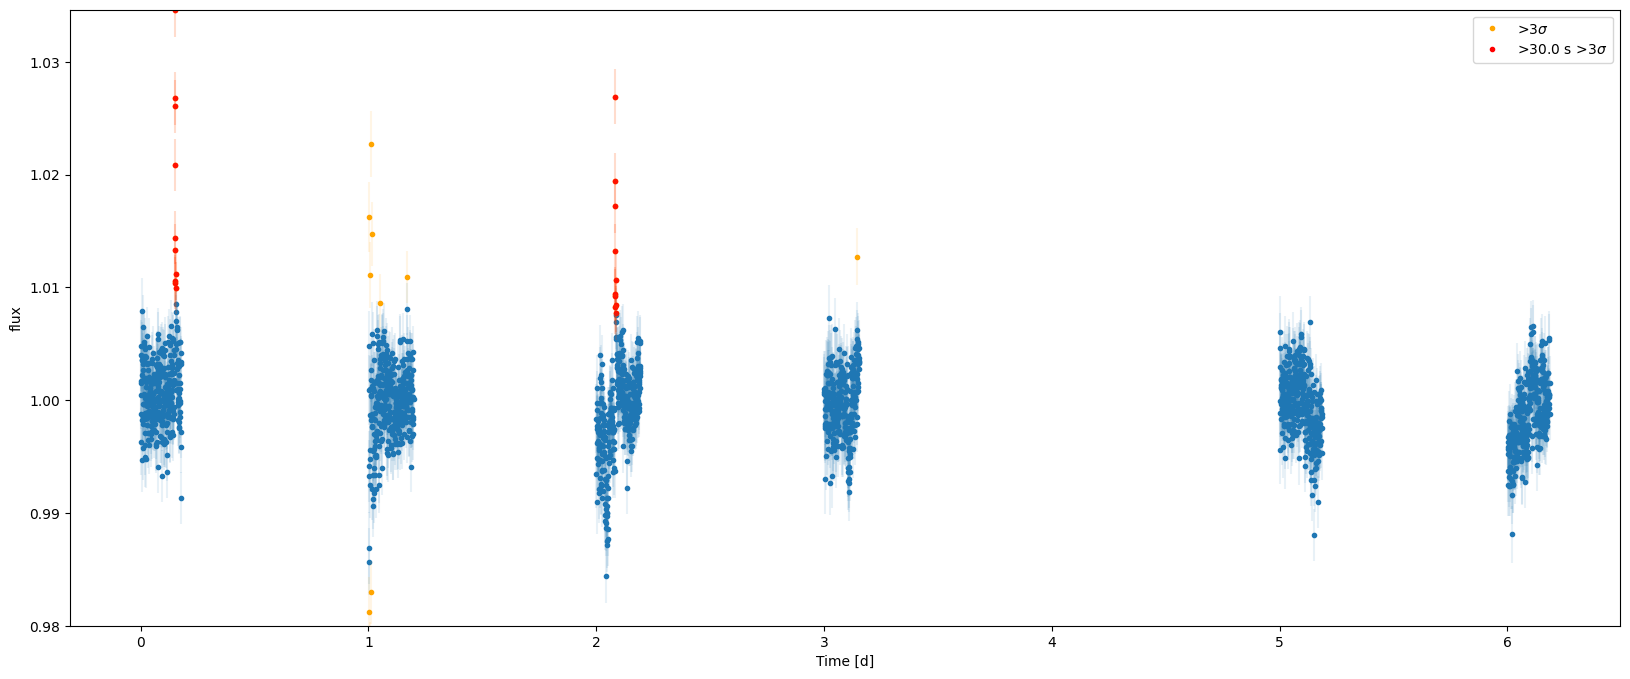

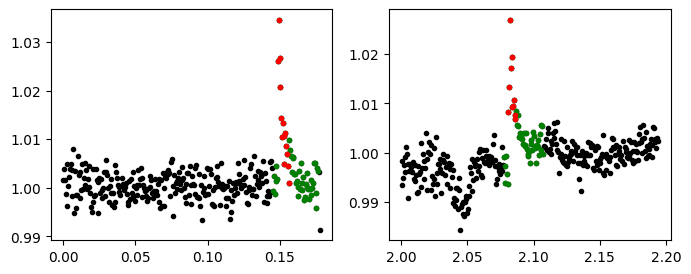

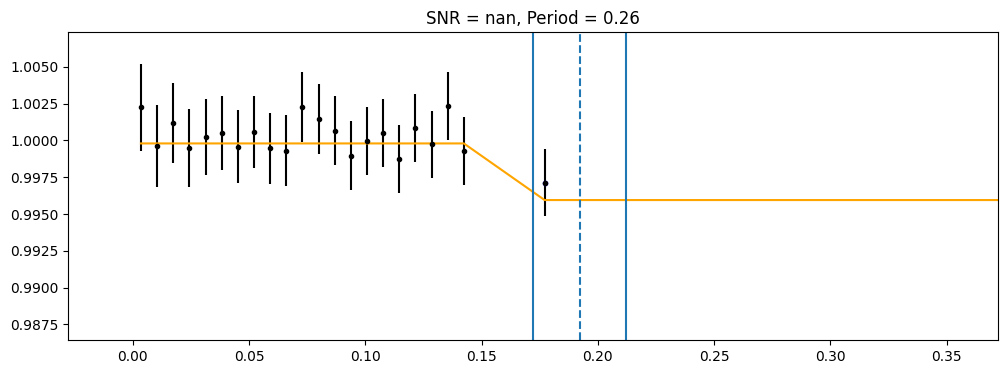

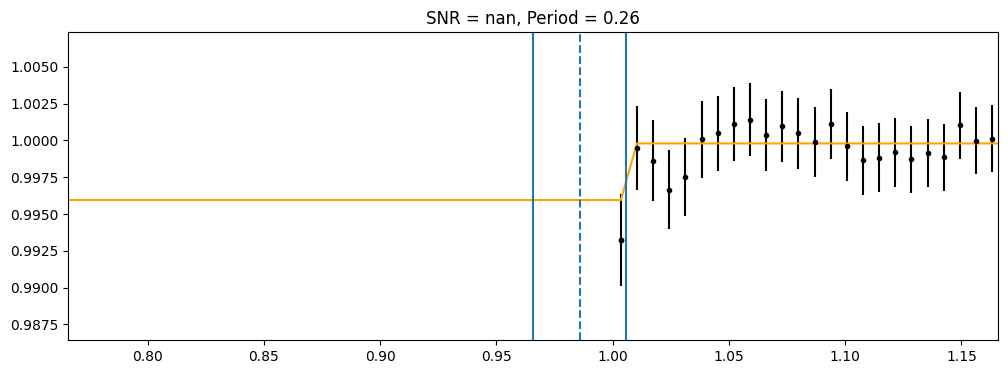

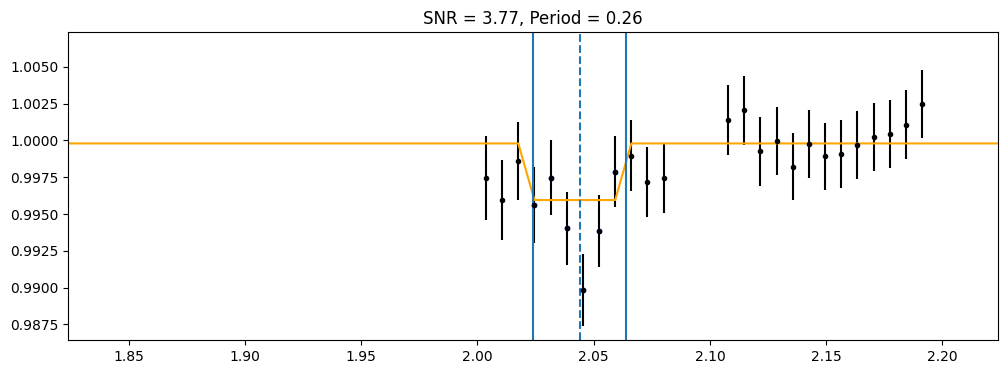

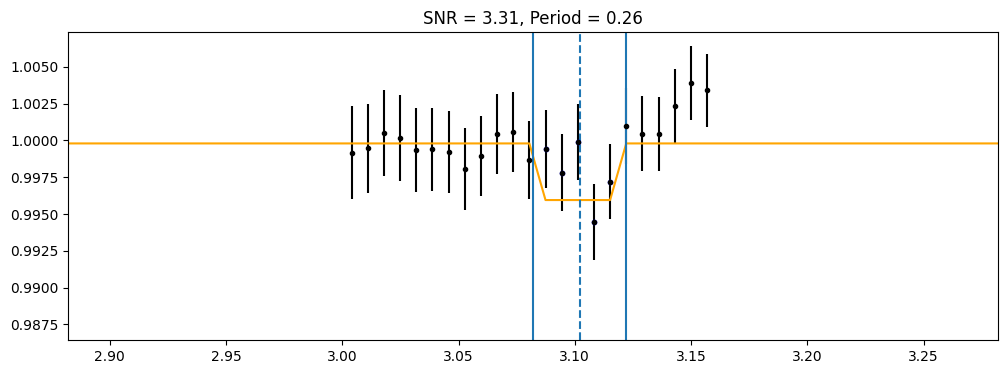

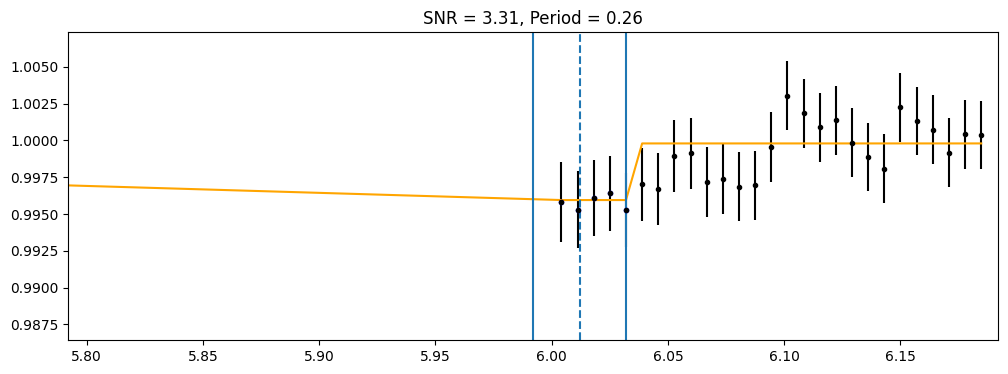

Time to BLS before detrending: 1.3877277374267578
Fitting rotation with square-exponential GP...
Initial Parameter Vector:  [-6.04127962 -6.46851513 -2.30258509]
Initial Params: AMP =  0.001551527844055413 , SQEXP=  0.10000000000000002 , JITTER =  0.0023785133622772504
Initial ln-likelihood: 270.27
Fitted GP HPs: [-27.66355865 -30.83924899  -1.07766769]
Fitted Params: AMP =  4.0428193491955864e-14 , SQEXP=  0.3403884927182667 , JITTER =  9.679861181968813e-13
Final ln-likelihood: 649.91


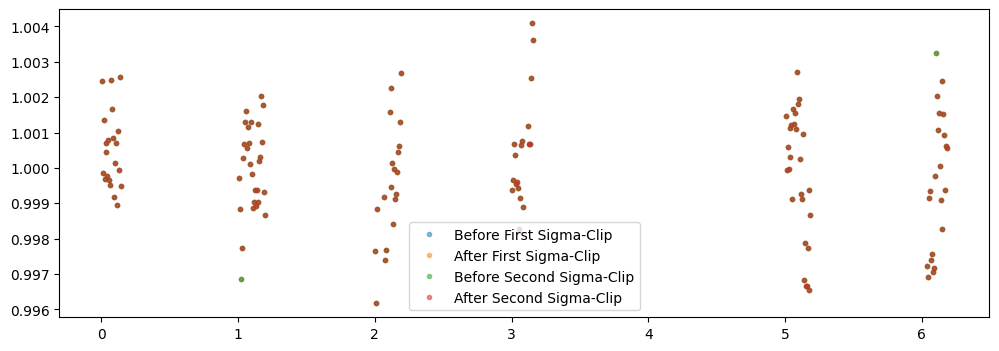

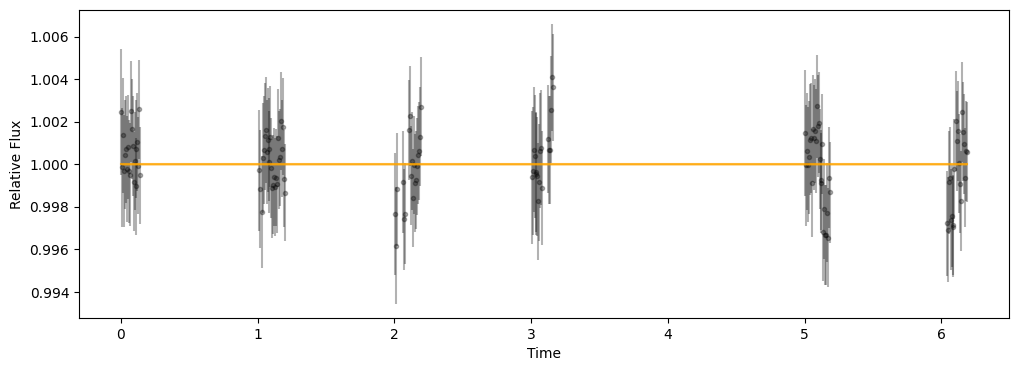

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Time to detrend: 1.9798681735992432


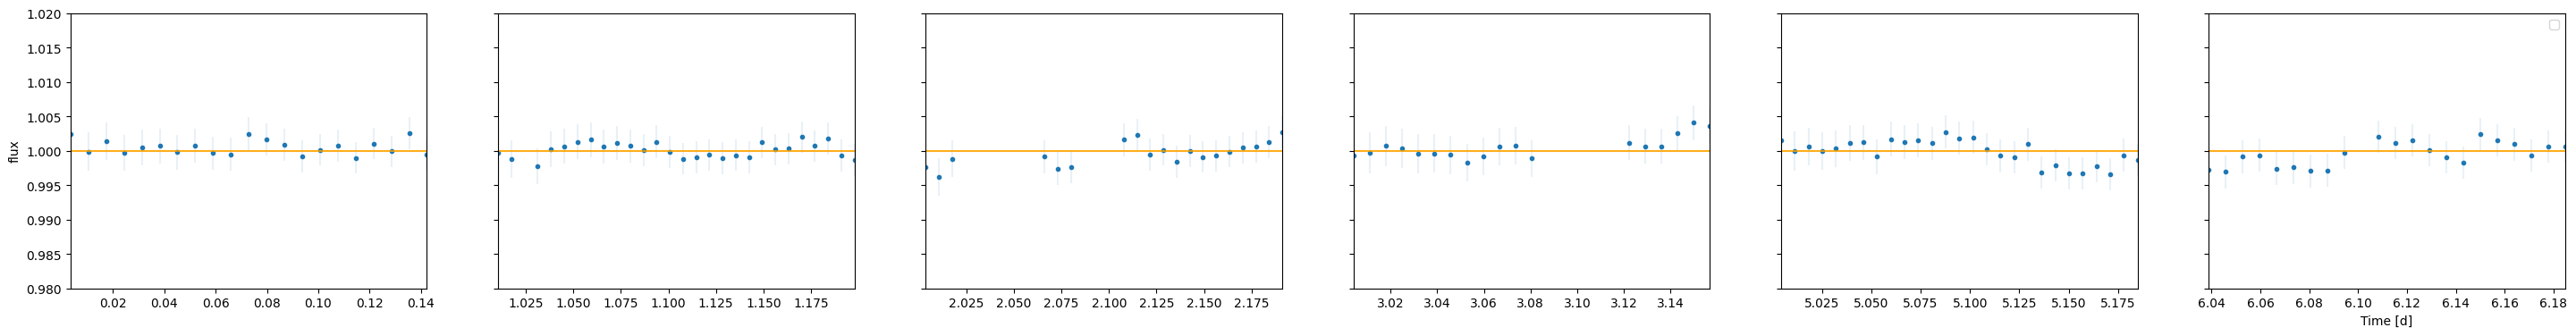

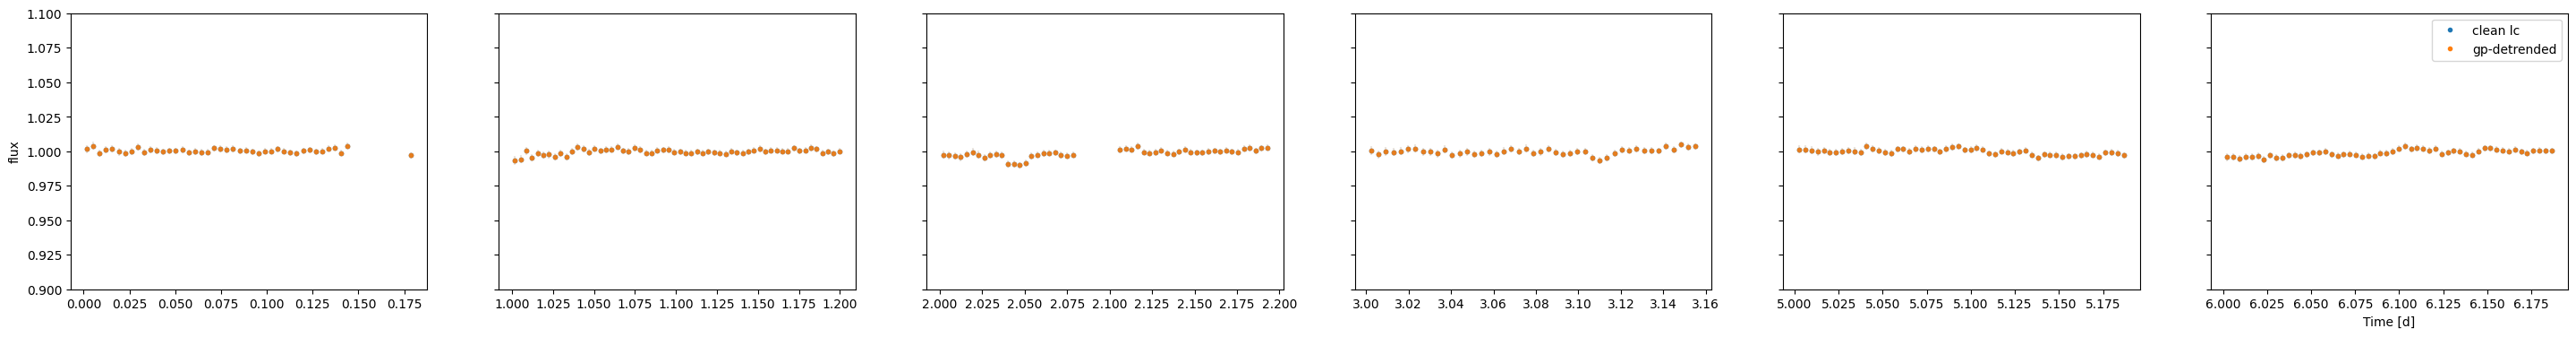

Running BLS Search
Number of Periods Checked:  47196
Period:  0.2086471663939469
Duration:  0.04
Depth:  0.003327863327314644
Power:  8.646798325538997


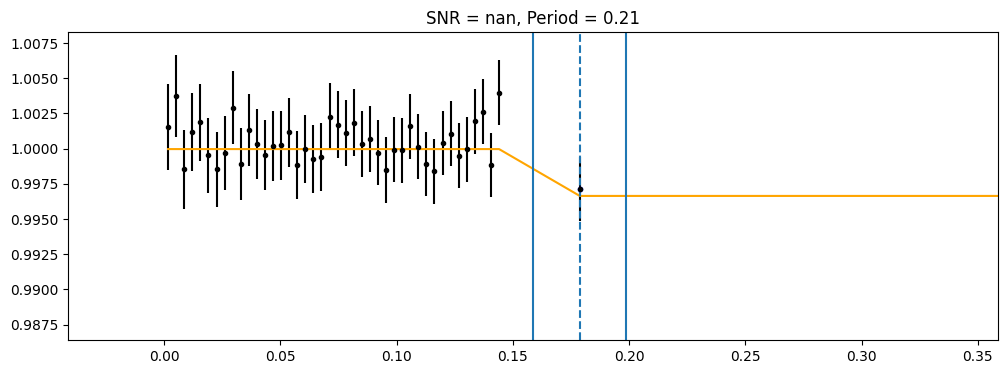

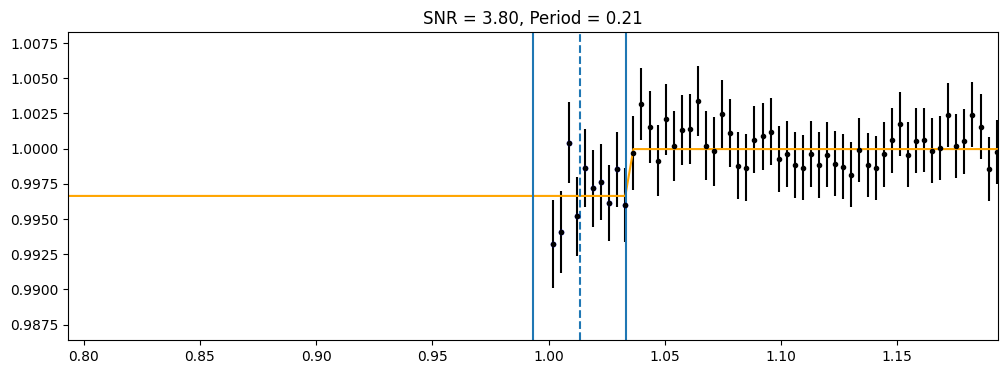

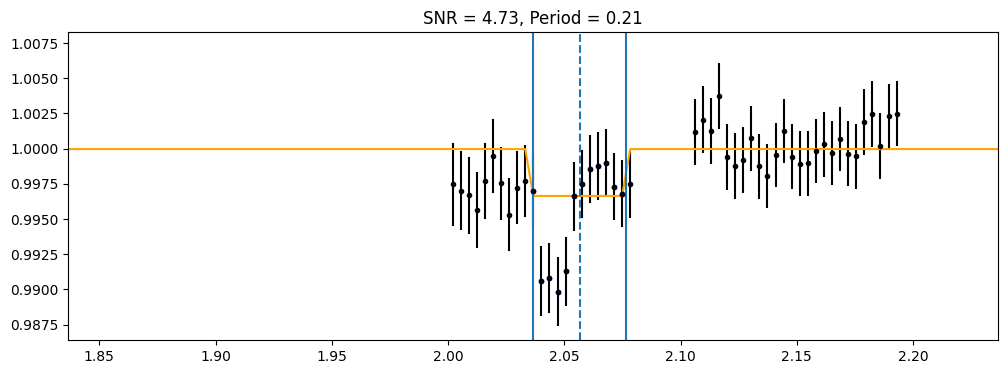

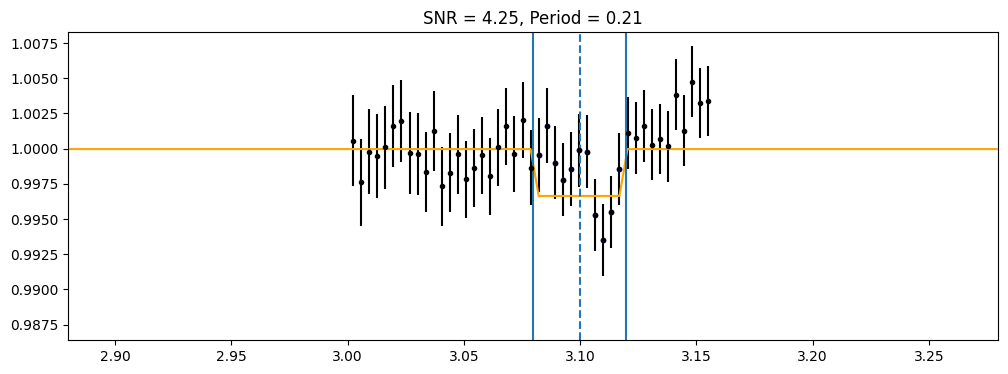

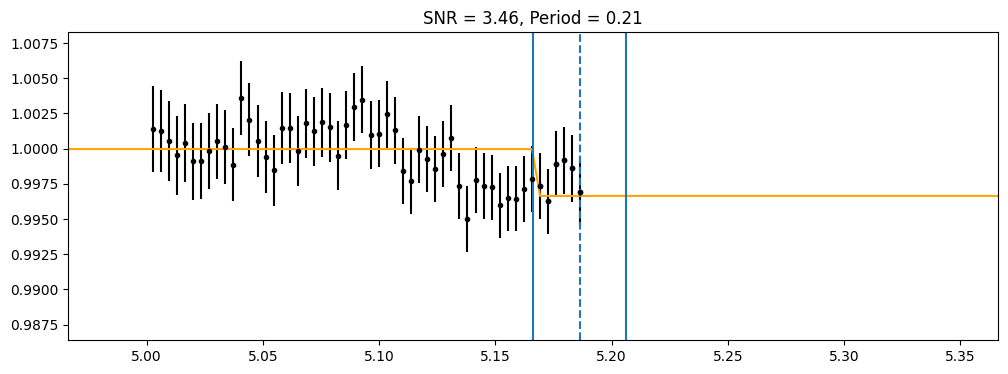

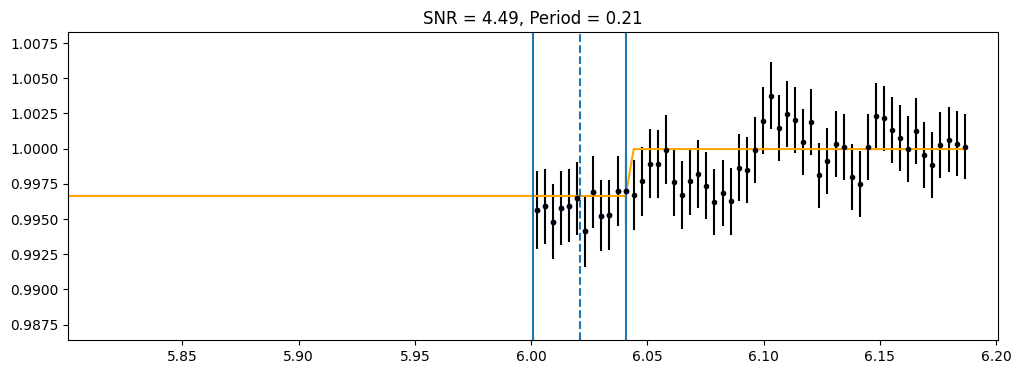

Time to BLS search: 1.292452096939087
Transit was found - checking if it matches the injected transit!
Planet was successfully recovered
No transit found!

Time to inject-recover 5 planets: 38.41015291213989
Planets recovered: 60.0%
But did all of those planets transited during the observation window?...
Observed Planets recovered: 60.0%


In [32]:
x = full_injection_recovery(targ, 
                            # lcs_with_transits=[targ_with_transit],
                                # planets=planets,
                             nfake=5,
                             minimum_planet_radius=0.25 * u.R_earth, 
                             maximum_planet_radius=1 * u.R_earth,
                             minimum_period=0.5 * u.d, 
                             maximum_period=2 * u.d, 
                             ld=[0.3,0.3],
                             clean_kw = {'dust_removal': False, 'bad_weather_removal': False,'cosmics_removal': True,
                                         'threshold_removal':False, 'cosmic_boxsize':0.01, 'cosmic_nsigma':5, 'verbose':True},
                             flare_kw = {'plot':True, 'min_flare_separation':60*u.minute, 'min_flare_duration':30*u.s,
                                         'tbuffer_after':30*u.min, 'n_consecutive_points':2, 'n_points':2, 
                                         'global_sc_kw':{'nsigma_upper': 3, 'nsigma_lower': 5}, 
                                         'local_sc_kw':{'nsigma_upper': 3, 'nsigma_lower': np.inf, 'running_median_boxsize': 0.2},},
                             detrend_method = "gp", 
                             detrend_bin = 10 * u.minute,
                             detrend_kw = {'do_first_sigma_clip': True, 'do_second_sigma_clip': True,
                                           'running_median_boxsize': 0.08, 'nsigma': 3, 'plot': True, 'verbose':True,
                                           'use_uncertainties':False, 'amp_metric':None, 'sqexp_metric':0.1, 
                                           'sqexp_metric_bound':[np.log((0.5*u.hr).to_value('d')), 
                                                                 np.log((np.max(targ.time)-np.min(targ.time)).value)]},
                            bls_kw = {"minimum_period":None, "maximum_period":None, 'minimum_n_transit':2, 'obj':'snr',
                                      'return_all_transits':False, 'transit_durations':[0.01,0.02,0.03,0.04], 'plot':True, 
                                      'verbose': True}, 
                            bls_bin=5 * u.minute,
                            recovery_kw = {'condition_on_epoch':1 * u.hour, 'min_n_transits': 1, 'meet_condition': 'any'},                           
                            verbose=True, plot=True, time_this_process=True)

In [10]:
lcs, lcs_clean, lcs_gp, lcs_bls, planets_df = x

In [22]:
lcs_bls[1]

[<🌟 Lightcurve secondLC_inject1_clean_sigmaclipped_flaresremoved_bin_bls_0 (302t) 🌟>]

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


False


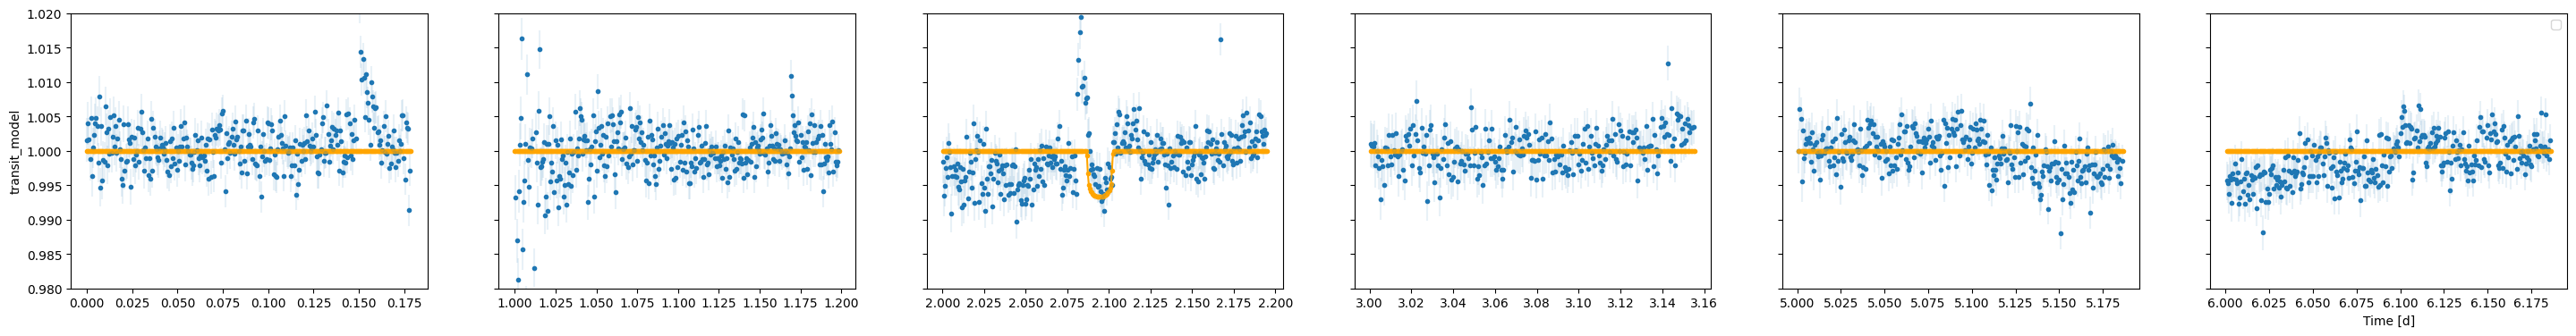

In [31]:
i=4
ax=lcs[i].plot()
lcs[i].plot(quantity="transit_model", color='orange', ax=ax, linestyle="-")
try:
    print(lcs_bls[i][0].metadata['BLS_transits_found'])
except:
    print(False)
    pass

In [45]:
# np.sqrt(planets_df['rec_depth']).values * 
from astropy.units import Quantity
planets_df['r_s'].apply(Quantity)

0    0.1 solRad
1    0.1 solRad
2    0.1 solRad
3    0.1 solRad
4    0.1 solRad
Name: r_s, dtype: object

Text(0.5, 0, 'Planet Radius [R_earth]')

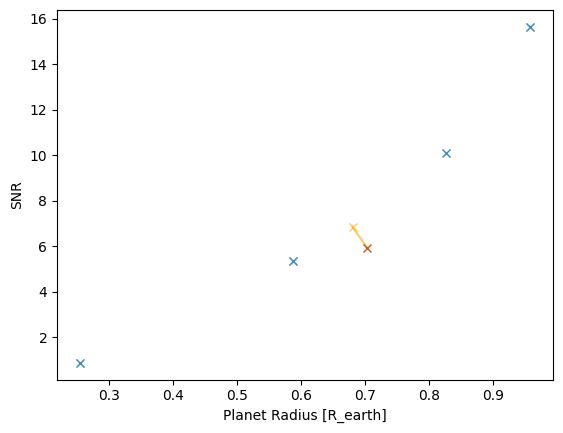

In [46]:
from astropy.units import Quantity

n_points_in_transit = planets_df['duration']/(7.5/(24*60))
lc_noise = 1e-3
rec_r_p = [x.to_value("R_earth") for x in (np.sqrt(planets_df['rec_depth']) * planets_df['r_s'].apply(Quantity)).values]

for r_p, depth, rec, r_p_rec, snr, n in zip(planets_df['r_p'], planets_df['depth'],  planets_df['recovered'],rec_r_p,  planets_df['snr'], n_points_in_transit):
    if rec == 1.0:
        color = "orange"
    else:
        color = "C0"
    if r_p_rec == 0.0:
        r_p_rec = r_p
        snr = depth * np.sqrt(n)/lc_noise
    plt.plot([r_p,r_p_rec], [depth * np.sqrt(n)/lc_noise, snr], 'x-', color=color, alpha=0.6)
    if rec == 1.0:
        plt.plot([r_p_rec], [snr], 'x', color='darkred', alpha=0.5)
plt.ylabel("SNR")
plt.xlabel("Planet Radius [R_earth]")

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


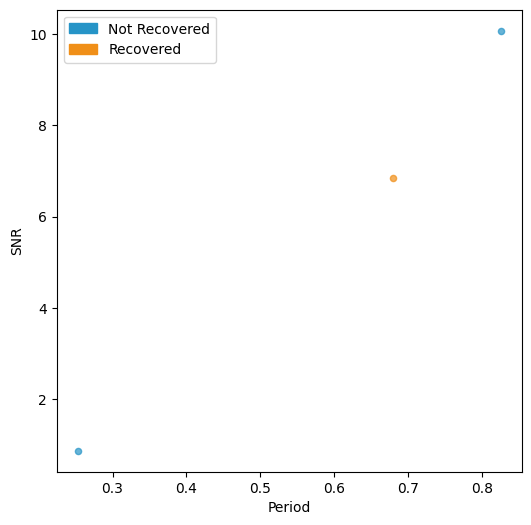

In [33]:
plot_transitparams(x=planets_df['r_p'][planets_df['observed'] == 1.0], 
                   y=planets_df['depth'][planets_df['observed'] == 1.0] * np.sqrt(n_points_in_transit[planets_df['observed'] == 1.0])/lc_noise, 
                   z=planets_df['recovered'][planets_df['observed'] == 1.0], 
                   xlabel="Period", 
                   ylabel="SNR", 
                   zlabel="Detected?", 
                   ylims=[], 
                   yscale='uniform',
                   xscale='uniform', 
                   add_points={}, 
                   pointsize=20,
                   svname="")